# Experiments — FastPart on 2D GMM with Fixed Identity Covariance

## Setting

We observe $n$ i.i.d. points $X_1,\ldots,X_n \in \mathbb{R}^2$ from a 2D Gaussian mixture
$$
f^0 = \sum_{k=1}^K a_k^0\, \mathcal{N}(\,\cdot\,;\, \theta_k^0,\, I_2), \qquad a_k^0 > 0.
$$
The goal is to **recover** the means $\{\theta_k^0\}$ and weights $\{a_k^0\}$ from the data, by minimising a regularised $L^2$ fitting criterion.

## BLASSO Problem

Let $\phi_\tau = \mathcal{N}(0, \tau^2 I_2)$ be the **smoothing Gaussian kernel** with bandwidth $\tau > 0$, and define the smoothed empirical distribution $\hat{f}_\tau^n = \frac{1}{n}\sum_i \phi_\tau(\cdot - X_i)$.

For a discrete positive measure $\mu = \sum_j a_j\,\delta_{\theta_j}$ ($a_j > 0$), the **BLASSO loss** is
$$
\mathcal{L}(\mu)
= \frac{1}{2}\|\phi_\tau * \mu - \hat{f}_\tau^n\|_{L^2(\mathbb{R}^2)}^2 + \kappa\,\|\mu\|_{\mathrm{TV}},
$$
where the total-variation norm reduces to $\|\mu\|_{\mathrm{TV}} = \sum_j a_j$ since all weights are positive.

**Expanding the $L^2$ term** using the feature map $\Phi_\tau(x;\theta) = \mathcal{N}(x;\,\theta,\,(1+\tau^2)I_2)$:
$$
\mathcal{L}(\mu)
= \frac{1}{2}\,\mathbf{a}^\top \mathbf{K}\,\mathbf{a}
  - \mathbf{a}^\top \mathbf{S}
  + \kappa\,\mathbf{1}^\top\mathbf{a}
  + C,
$$
with:
- **Gram matrix** $K_{ij} = \langle\Phi_\tau(\theta_i),\Phi_\tau(\theta_j)\rangle_{L^2} = \mathcal{N}(\theta_i;\,\theta_j,\,2(1+\tau^2)I_2)$,
- **Scalar products** $S_j = \langle\hat{f}_\tau^n, \Phi_\tau(\theta_j)\rangle_{L^2} = \frac{1}{n}\sum_i \mathcal{N}(X_i;\,\theta_j,\,(1+2\tau^2)I_2)$,
- **Constant offset** $C = \frac{1}{2}\|\hat{f}_\tau^n\|_{L^2}^2 = \frac{1}{2n\,(4\pi\tau^2)}$.

## Dual Certificate and Optimality

The **BLASSO dual variable** (first-order derivative w.r.t. the measure) is
$$
J'_\nu(\theta)
= \kappa + (\mathbf{K}\mathbf{a})(\theta) - S(\theta).
$$
First-order optimality requires $J'_\nu(\theta) \geq 0$ everywhere, with $J'_\nu(\theta_j) = 0$ at each support point $\theta_j$ such that $a_j > 0$.

## Discrete Parameterisation

We reparametrise $a_j = h(r_j) = r_j^2$ so that **amplitudes are always positive** without constraints on $r_j \in \mathbb{R}$. Positions $\theta_j \in \mathbb{R}^2$ are updated via Euclidean gradient descent.

There is **no Riemannian geometry** (no manifold structure on positions) and **no sketching** in this experiment.


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Any, Callable, TypeVar, Generic, ClassVar
from dataclasses import dataclass, field
from abc import ABC, abstractmethod
from functools import cached_property
from torch.nn import Module, Parameter
from torch import Tensor
from jaxtyping import Float, Int

# Reproducibility
torch.manual_seed(314)
np.random.seed(314)

# Check for NVIDIA GPU (CUDA)
if torch.cuda.is_available():
    device = torch.device("cuda")
# Check for Apple Silicon GPU (MPS)
elif torch.backends.mps.is_available():
    device = torch.device("mps")
# Fallback to CPU
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


## Base Framework

The BLASSO optimisation relies on the following class hierarchy:

| Class | Role |
|-------|------|
| `Particles` | Discrete measure $\mu_p = \sum_i h(r_i)\,\delta_{\theta_i}$; holds `positions` $(\theta_i)$ and `weights` $(r_i)$ as `nn.Parameter` |
| `BlassoProblem` | Abstract base: stores $\kappa$, $y$; `__call__(particles)` returns a lazy `Evaluation` |
| `L2Blasso` | Concrete subclass: $\mathcal{L} = \frac{1}{2}\mathbf{a}^\top K\mathbf{a} - \mathbf{a}^\top S + \kappa\|\mathbf{a}\|_1 + C$; delegates `kernel` and `scalar_products` to each subproblem |
| `ConicOptimizer` | Abstract interface for gradient-based solvers |
| `Retraction` | Euclidean update $r \leftarrow r - \eta\,\nabla_r\mathcal{L}$ |
| `MirrorRetraction` | Mirror update $r \leftarrow r\cdot e^{-\eta\,\nabla_r\mathcal{L}}$ (preserves positivity of $r$) |

The `Evaluation` inner class uses `cached_property` so that `kernel` and `scalar_products` are computed **at most once** per forward pass, even if queried multiple times (e.g. by the optimizer and a birth–death step).

> **Autograd strategy**: the loss $\mathcal{L}$ is a scalar function of `positions` and `weights` through the `kernel` and `scalar_products` tensors. Calling `ev.backward()` populates `.grad` on both parameter tensors, which the optimizer then reads.


In [2]:
# ============================================================================
# RETRACTION CLASSES
# ============================================================================

class Retraction:
    """Default (Euclidean) retraction: additive update."""

    def __call__(
        self,
        positions: Tensor,
        weights: Tensor,
        dpositions: Tensor,
        dweights: Tensor,
    ) -> None:
        positions += dpositions
        weights += dweights


class MirrorRetraction(Retraction):
    """Mirror retraction: multiplicative update for weights."""

    def __call__(
        self,
        positions: Tensor,
        weights: Tensor,
        dpositions: Tensor,
        dweights: Tensor,
    ) -> None:
        positions += dpositions
        weights *= torch.exp(dweights)


# ============================================================================
# PARTICLES CLASS
# ============================================================================

class Particles(Module):
    r"""
    A class for encoding a discrete measure
    $\mu_p = \sum_i h(r_i) \delta_{\theta_i}$
    where $r_i$ is a raw weight and $\theta_i$ a position.
    """

    def __init__(
        self,
        h: Callable[[Float[Tensor, " n"]], Float[Tensor, " n"]],
        positions: Float[Tensor, "n dim"],
        weights: Float[Tensor, " n"],
        signs: Int[Tensor, " n"],
    ):
        n_particles, _ = positions.shape
        assert weights.shape == (n_particles,)
        assert signs.shape == (n_particles,)

        super().__init__()
        self.h = h
        self.positions = Parameter(positions)
        self.weights = Parameter(weights)
        self.signs = signs
        self.gradient_evaluation = None

    @staticmethod
    def from_randn(
        h: Callable,
        dimension: int,
        n_particles: int,
        position_sigma: float = 1.0,
        weight_sigma: float = 1.0,
        **kwargs: Any,
    ) -> "Particles":
        positions = Parameter(
            position_sigma * torch.randn((n_particles, dimension), **kwargs)
        )
        weights = Parameter(weight_sigma * torch.randn(n_particles, **kwargs).abs())
        signs = torch.ones(n_particles)
        return Particles(h, positions, weights, signs)

    @property
    def amplitudes(self) -> Float[Tensor, " n"]:
        """True weights $a_i = h(r_i)$ in front of each Dirac."""
        return self.h(self.weights)

    @property
    def amplitudes_deriv(self) -> Float[Tensor, " n"]:
        """Derivative of h with respect to raw weights."""
        with torch.enable_grad():
            amplitudes = self.amplitudes
            return torch.autograd.grad(
                amplitudes,
                self.weights,
                grad_outputs=torch.ones_like(amplitudes),
            )[0]

    def __len__(self) -> int:
        return self.positions.size(0)

    def tv_norm(self) -> Float[Tensor, "1"]:
        """TV-norm of the discrete particle measure."""
        return self.amplitudes.abs().sum()

    def clone(self, *, detach: bool = True) -> "Particles":
        """Return a copy of Particles."""
        positions = self.positions.detach().clone() if detach else self.positions.clone()
        weights = self.weights.detach().clone() if detach else self.weights.clone()
        signs = self.signs.clone()
        return Particles(h=self.h, positions=positions, weights=weights, signs=signs)

    def __repr__(self) -> str:
        return (
            f"{type(self).__name__}("
            f"positions={self.positions.data}, "
            f"weights={self.weights.data})"
        )


# ============================================================================
# BASE PROBLEM CLASSES
# ============================================================================

TProblem = TypeVar("TProblem", bound="BlassoProblem")


@dataclass
class ModelEvaluation(Generic[TProblem]):
    """Evaluation context when computing the BLASSO loss."""

    problem: TProblem
    particles: Particles

    def set_particles_gradient(
        self,
        dweights: Float[Tensor, " n"],
        dpositions: Float[Tensor, "n dim"],
    ) -> None:
        self.particles.weights.grad = dweights
        self.particles.positions.grad = dpositions
        self.particles.gradient_evaluation = self

    @cached_property
    def proximity(self) -> Float[Tensor, "1"]:
        raise NotImplementedError

    @cached_property
    def lasso(self) -> Float[Tensor, "1"]:
        return self.problem.kappa * self.particles.tv_norm()

    @cached_property
    def loss(self) -> Float[Tensor, "1"]:
        return self.proximity + self.lasso

    @cached_property
    def Fm_backward(self) -> None:
        dweights, dpositions = torch.autograd.grad(
            self.loss,
            [self.particles.weights, self.particles.positions],
        )
        self.set_particles_gradient(dweights, dpositions)

    @cached_property
    def amplitudes(self) -> Float[Tensor, " n"]:
        return self.particles.amplitudes

    @cached_property
    def amplitudes_deriv(self) -> Float[Tensor, " n"]:
        return self.particles.amplitudes_deriv

    @cached_property
    def loss_backward(self) -> None:
        """Fallback to autograd."""
        self.Fm_backward

    @cached_property
    def loss_gradient(self) -> list[Tensor]:
        self.loss_backward
        return [p.grad for p in self.particles.parameters()]

    def backward(self) -> None:
        self.loss_backward

    def item(self) -> float:
        return self.loss.item()


@dataclass
class BlassoProblem(ABC):
    """Base class for a BLASSO problem."""

    Evaluation: ClassVar[type[ModelEvaluation]] = ModelEvaluation

    kappa: float

    def __call__(self, particles: Particles) -> ModelEvaluation:
        return self.Evaluation(self, particles)


# ============================================================================
# L2 BLASSO
# ============================================================================

Observation = TypeVar("Observation")


@dataclass
class L2Blasso(BlassoProblem, Generic[Observation]):
    y: Observation
    loss_offset: float = field(init=False, default=0.0)

    @dataclass
    class Evaluation(ModelEvaluation["L2Blasso"]):

        @cached_property
        def kernel(self) -> Float[Tensor, "n n"]:
            """Gram matrix: K[i,j] = <phi(theta_i), phi(theta_j)>."""
            raise NotImplementedError

        @cached_property
        def scalar_products(self) -> Float[Tensor, " n"]:
            """Vector: S[i] = <hat_f_tau, phi(theta_i)>."""
            raise NotImplementedError

        @cached_property
        def l2_cost(self) -> Float[Tensor, "1"]:
            a = self.particles.amplitudes
            K = self.kernel
            S = self.scalar_products
            return 0.5 * a @ (K @ a) - a @ S + self.problem.loss_offset

        @cached_property
        def proximity(self) -> Float[Tensor, "1"]:
            return self.l2_cost


# ============================================================================
# OPTIMIZER
# ============================================================================

@dataclass
class Optimizer(ABC):
    particles: Particles

    def zero_grad(self) -> None:
        self.particles.zero_grad()

    @abstractmethod
    def step(self) -> None: ...


@dataclass
class ConicOptimizer(Optimizer):
    r"""
    Conic Particle Gradient Descent optimizer (Chizat 2022).

    Update rule:
        theta_i <- theta_i - beta * grad_{theta_i} J'(theta_i)
        r_i     <- r_i     - alpha * J'(theta_i)
    where J'(theta) = kappa + (K a)[theta] - S[theta].
    Falls back to autograd-based gradients if Jp is not implemented.
    """

    alpha: float
    beta: float
    retraction: Retraction = field(default_factory=Retraction)

    def step(self) -> None:
        positions = self.particles.positions
        weights = self.particles.weights
        amplitudes = self.particles.amplitudes
        amplitudes_deriv = self.particles.amplitudes_deriv

        assert positions.grad is not None
        assert weights.grad is not None
        assert self.particles.gradient_evaluation is not None

        with torch.no_grad():
            # Gradient w.r.t. raw weights
            grad_weights = self.alpha * weights.grad / amplitudes_deriv
            grad_weights[amplitudes_deriv == 0] = 0.0

            # Gradient w.r.t. positions
            eps = amplitudes.unsqueeze(-1)
            grad_positions = torch.zeros_like(positions)
            mask = eps.squeeze(-1) != 0
            grad_positions[mask] = (
                self.beta / eps[mask] * positions.grad[mask]
            )

            self.retraction(positions, weights, -grad_positions, -grad_weights)


print("✓ Base classes loaded.")

✓ Base classes loaded.


## Fixed-Covariance GMM: Derivation of Kernel and Scalar Products

We set dimension $d=2$ and consider a Gaussian smoothing kernel $\phi_\tau = \mathcal{N}(0, \tau^2 I_2)$.

### Feature Map

Convolving the model component $\mathcal{N}(\cdot;\,\theta, I_2)$ with the smoothing kernel gives
$$
\Phi_\tau(x;\,\theta)
= \bigl(\mathcal{N}(\cdot;\,\theta, I_2) * \phi_\tau\bigr)(x)
= \mathcal{N}\!\left(x;\;\theta,\;(1+\tau^2)\,I_2\right).
$$
This is well-defined because the convolution of two Gaussians is Gaussian, and covariances add.

### Gram Matrix

With $\sigma^2 := 1 + \tau^2$, the inner product in $L^2(\mathbb{R}^2)$ is
$$
K(\theta_i, \theta_j)
= \int_{\mathbb{R}^2} \Phi_\tau(x;\,\theta_i)\,\Phi_\tau(x;\,\theta_j)\,\mathrm{d}x
= \mathcal{N}\!\left(\theta_i;\;\theta_j,\;2\sigma^2 I_2\right)
= \frac{1}{4\pi\sigma^2}\exp\!\left(-\frac{\|\theta_i - \theta_j\|^2}{4\sigma^2}\right).
$$
Note that the **self-kernel is constant**: $K(\theta,\theta) = \frac{1}{4\pi\sigma^2}$ for all $\theta \in \mathbb{R}^2$. This simplifies the birth–death score computation considerably.

### Scalar Products with the Smoothed Empirical Measure

Let $\hat f_\tau^n = \frac{1}{n}\sum_{i=1}^n \phi_\tau(\cdot - X_i)$. Then
$$
S(\theta_j)
= \langle \hat{f}_\tau^n,\, \Phi_\tau(\cdot;\,\theta_j)\rangle_{L^2}
= \frac{1}{n}\sum_{i=1}^n \int_{\mathbb{R}^2} \phi_\tau(x - X_i)\,\Phi_\tau(x;\,\theta_j)\,\mathrm{d}x
= \frac{1}{n}\sum_{i=1}^n \mathcal{N}\!\left(X_i;\;\theta_j,\;(1+2\tau^2)\,I_2\right).
$$

### Loss Constant

$$
C
= \frac{1}{2}\|\hat{f}_\tau^n\|_{L^2}^2
= \frac{1}{2}\cdot\frac{1}{n^2}\sum_{i,j}\int \phi_\tau(x-X_i)\phi_\tau(x-X_j)\,\mathrm{d}x
= \frac{1}{2n^2}\sum_{i,j}\mathcal{N}(X_i; X_j, 2\tau^2 I_2)
\approx \frac{1}{2n\,(4\pi\tau^2)}.
$$
In practice, we use the diagonal approximation $C \approx \frac{1}{2n\,(4\pi\tau^2)}$ (terms $i \neq j$ contribute small cross-terms when $n$ is large).

### Dual Certificate (J')

Putting it all together, the first-order derivative of the BLASSO loss with respect to a Dirac mass at $\theta$ is
$$
J'_\nu(\theta)
= \kappa
+ \sum_j a_j\, K(\theta, \theta_j)
- S(\theta).
$$
This quantity governs the **CPGD update rule** for positions (gradient is $\nabla_\theta J'_\nu$) and for weights (the descent direction is $J'_\nu(\theta_j)$ itself).


In [3]:

# ============================================================================
# DATA GENERATION
# ============================================================================

def generate_gmm_data(
    means: Float[Tensor, "K 2"],
    weights: Float[Tensor, " K"],
    n_samples: int,
    seed: Optional[int] = None,
) -> Float[Tensor, "n 2"]:
    r"""
    Generate i.i.d. samples from the 2D GMM
        f^0 = sum_k  a_k  N(·; mu_k, I_2)

    Parameters
    ----------
    means : (K, 2) tensor — component means.
    weights : (K,) tensor — positive mixture weights (need not sum to 1;
        they are normalised internally).
    n_samples : number of observations to draw.
    seed : optional random seed.

    Returns
    -------
    X : (n_samples, 2) tensor of samples.
    """
    if seed is not None:
        torch.manual_seed(seed)

    K = means.shape[0]
    assert means.shape == (K, 2), "means must be (K, 2)"
    assert weights.shape == (K,), "weights must be (K,)"
    assert (weights > 0).all(), "all weights must be positive"

    probs = weights / weights.sum()
    component_idx = torch.multinomial(probs, n_samples, replacement=True)
    selected_means = means[component_idx]          # (n_samples, 2)
    noise = torch.randn(n_samples, 2)
    X = selected_means + noise
    return X


# ============================================================================
# FIXED-COVARIANCE GMM PARTICLES
# ============================================================================

class FixedCovGMMParticles(Particles):
    r"""
    Particles for a 2D GMM with **fixed identity covariance**.

    Parameterisation: theta in R^2 (mean), a = h(r) = r^2 (amplitude > 0).
    """

    def __init__(
        self,
        positions: Float[Tensor, "n 2"],
        weights: Float[Tensor, " n"],
    ):
        n = positions.shape[0]
        assert positions.shape == (n, 2)
        assert weights.shape == (n,)
        h = lambda r: r**2
        signs = torch.ones(n)
        super().__init__(h=h, positions=positions, weights=weights, signs=signs)

    @staticmethod
    def from_randn(
        n_particles: int,
        position_sigma: float = 1.0,
        weight_scale: float = 1.0,
        **kwargs: Any,
    ) -> "FixedCovGMMParticles":
        positions = position_sigma * torch.randn((n_particles, 2), **kwargs)
        weights = weight_scale * torch.rand(n_particles, **kwargs)
        return FixedCovGMMParticles(positions, weights)

    @staticmethod
    def from_positions(
        positions: Float[Tensor, "n 2"],
        weight_scale: float = 1.0,
    ) -> "FixedCovGMMParticles":
        n = positions.shape[0]
        weights = weight_scale * torch.ones(n)
        return FixedCovGMMParticles(positions.clone(), weights)

    def clone(self, *, detach: bool = True) -> "FixedCovGMMParticles":
        positions = self.positions.detach().clone() if detach else self.positions.clone()
        weights = self.weights.detach().clone() if detach else self.weights.clone()
        return FixedCovGMMParticles(positions, weights)


# ============================================================================
# FIXED-COVARIANCE GMM BLASSO PROBLEM
# ============================================================================

_MC_OFFSET_THRESHOLD = 10_000   # switch to Monte Carlo above this sample size
_MC_OFFSET_SIZE      = 10_000   # number of MC points used for the estimate

@dataclass
class FixedCovGMMBlasso(L2Blasso[Tensor]):
    r"""
    BLASSO problem for a 2D GMM with fixed identity covariance.

    Feature map:      Phi_tau(x; theta) = N(x; theta, (1+tau^2) I)
    Gram matrix:      K(ti, tj)         = N(ti; tj, 2*(1+tau^2) I)
    Scalar products:  S(tj)             = (1/n) sum_i N(Xi; tj, (1+2*tau^2) I)
    Loss offset:      C = (1/2)||hat_f_tau^n||^2_{L2}
                        = 1/(2n^2) sum_{i,j} N(Xi; Xj, 2*tau^2 I)
                      Computation strategy:
                        n <= 10 000 : exact O(n^2) double sum.
                        n >  10 000 : Monte Carlo estimate on m=10 000 random
                                      points drawn without replacement from X:
                                      C ≈ 1/(2m^2) sum_{i,j in S} N(Xi;Xj, 2*tau^2 I).
                      C = 0 when skip_offset=True (safe for gradient steps).
    """

    tau: float
    skip_offset: bool = False  # True for mini-batch problems — avoids O(n^2) per-step cost
    d: int = field(init=False, default=2)

    def __post_init__(self) -> None:
        import math
        n, self.d = self.y.shape
        assert self.d == 2, "Only 2D data is supported."
        if self.skip_offset:
            # loss_offset is a constant w.r.t. particles — setting it to 0
            # does not affect gradients, only shifts the displayed loss value.
            self.loss_offset = 0.0
            return
        s2 = 2.0 * self.tau**2
        log_norm = (self.d / 2.0) * math.log(2.0 * math.pi * s2)
        with torch.no_grad():
            if n <= _MC_OFFSET_THRESHOLD:
                # Exact computation: O(n^2)
                Y = self.y
                print(f"  loss_offset: exact O(n^2) computation (n={n})")
            else:
                # Monte Carlo estimate: subsample m points without replacement
                m = _MC_OFFSET_SIZE
                idx = torch.randperm(n)[:m]
                Y = self.y[idx]
                print(f"  loss_offset: Monte Carlo estimate (n={n} > {_MC_OFFSET_THRESHOLD}, m={m})")
            diff    = Y[:, None, :] - Y[None, :, :]   # (m, m, 2)
            sq_dist = (diff**2).sum(dim=-1)            # (m, m)
            log_phi = -sq_dist / (2.0 * s2) - log_norm
            self.loss_offset = float(0.5 * torch.exp(log_phi).mean())

    @dataclass
    class Evaluation(L2Blasso.Evaluation):

        @cached_property
        def _sigma2_kernel(self) -> float:
            return 2.0 * (1.0 + self.problem.tau**2)

        @cached_property
        def _sigma2_scalar(self) -> float:
            return 1.0 + 2.0 * self.problem.tau**2

        @cached_property
        def kernel(self) -> Float[Tensor, "n n"]:
            import math
            theta = self.particles.positions          # (p, 2)
            s2 = self._sigma2_kernel
            d  = self.problem.d
            diff    = theta[:, None, :] - theta[None, :, :]  # (p, p, 2)
            sq_dist = (diff**2).sum(dim=-1)                   # (p, p)
            log_norm = (d / 2.0) * math.log(2.0 * math.pi * s2)
            log_K   = -sq_dist / (2.0 * s2) - log_norm
            return torch.exp(log_K)

        @cached_property
        def scalar_products(self) -> Float[Tensor, " n"]:
            import math
            X     = self.problem.y                         # (n, 2)
            theta = self.particles.positions               # (p, 2)
            s2    = self._sigma2_scalar
            d     = self.problem.d
            # Ensure X is on the same device as theta
            X = X.to(theta.device)
            diff    = theta[:, None, :] - X[None, :, :]   # (p, n, 2)
            sq_dist = (diff**2).sum(dim=-1)                # (p, n)
            log_norm = (d / 2.0) * math.log(2.0 * math.pi * s2)
            log_phi = -sq_dist / (2.0 * s2) - log_norm
            return torch.exp(log_phi).mean(dim=1)          # (p,)


FixedCovGMMBlasso.Evaluation = FixedCovGMMBlasso.Evaluation

print("✓ FixedCovGMMParticles, FixedCovGMMBlasso and generate_gmm_data loaded.")


✓ FixedCovGMMParticles, FixedCovGMMBlasso and generate_gmm_data loaded.


## Smoke Test — Forward and Backward Passes

We verify the following before training:

1. **`FixedCovGMMParticles`**: raw weights $r_i$ are stored as parameters; amplitudes $a_i = r_i^2$ are positive.
2. **`FixedCovGMMBlasso.Evaluation`**: the `kernel` property returns the correct $(p \times p)$ Gram matrix $K$, and `scalar_products` returns the $(p,)$ vector $S$.
3. **Loss value**: $\mathcal{L} = \frac{1}{2}\mathbf{a}^\top K\mathbf{a} - \mathbf{a}^\top S + \kappa\|\mathbf{a}\|_1 + C$ should be a finite non-negative scalar.
4. **Autograd**: calling `ev.backward()` fills `.grad` with non-zero gradients on `positions` and `weights`, confirming that the computation graph is intact.


In [4]:
# ---- Ground-truth GMM (user-defined parameter: number of components) --------
K_true = 25                  # <--- only this needs to be changed
CIRCLE_RADIUS = 30         # radius of the circle on which means are placed
DIRICHLET_CONCENTRATION = 1.0  # Dirichlet concentration parameter (1 = uniform)

# Equally spaced means on a circle of radius CIRCLE_RADIUS
angles = torch.linspace(0, 2 * torch.pi, K_true + 1)[:-1]  # angles 0, 2π/K, ..., 2π(K-1)/K
true_means = CIRCLE_RADIUS * torch.stack([torch.cos(angles), torch.sin(angles)], dim=1)

# Weights drawn from a Dirichlet distribution
torch.manual_seed(31415)  # for reproducibility
concentration = DIRICHLET_CONCENTRATION * torch.ones(K_true)
true_weights = torch.distributions.Dirichlet(concentration).sample()

print(f"Ground-truth GMM: K={K_true} components")
for k in range(K_true):
    print(f"  Component {k}: mean={true_means[k].tolist()},  weight={true_weights[k].item():.4f}")

# ---- Generate observations ----

n_samples = 100_000
tau = 1e-2  # smoothing bandwidth

X = generate_gmm_data(true_means, true_weights, n_samples, seed=42)
print(f"\nObservations X: shape={X.shape}, mean={X.mean(0).tolist()}")

# ---- Initialise particles ----
n_particles = 20
particles = FixedCovGMMParticles.from_randn(n_particles, position_sigma= 0.5 * CIRCLE_RADIUS, weight_scale=1.0, device=device)
print(f"Particles: {len(particles)} particles, amplitudes={particles.amplitudes.detach().tolist()}")

# ---- Initialise problem ----
kappa = 1e-3
problem = FixedCovGMMBlasso(kappa=kappa, y=X, tau=tau)
print(f"Problem: kappa={problem.kappa}, tau={problem.tau}, loss_offset={problem.loss_offset:.6f}")

# ---- Forward pass ----
ev = problem(particles)
print(f"kernel shape: {ev.kernel.shape}")
print(f"scalar_products shape: {ev.scalar_products.shape}")
print(f"l2_cost = {ev.l2_cost.item():.6f}")
print(f"lasso   = {ev.lasso.item():.6f}")
print(f"loss    = {ev.loss.item():.6f}")

# ---- Backward pass (autograd) ----
ev.backward()
print(f"grad positions norm: {particles.positions.grad.norm().item():.4f}")
print(f"grad weights norm:   {particles.weights.grad.norm().item():.4f}")
print("✓ Forward and backward passes succeed.")


Ground-truth GMM: K=25 components
  Component 0: mean=[30.0, 0.0],  weight=0.0036
  Component 1: mean=[29.0574951171875, 7.460697174072266],  weight=0.0396
  Component 2: mean=[26.289199829101562, 14.452610969543457],  weight=0.0014
  Component 3: mean=[21.869056701660156, 20.536413192749023],  weight=0.2142
  Component 4: mean=[16.07480239868164, 25.329837799072266],  weight=0.0034
  Component 5: mean=[9.270508766174316, 28.531696319580078],  weight=0.0005
  Component 6: mean=[1.883711338043213, 29.9408016204834],  weight=0.0234
  Component 7: mean=[-5.621442794799805, 29.468616485595703],  weight=0.0063
  Component 8: mean=[-12.773382186889648, 27.14480972290039],  weight=0.0259
  Component 9: mean=[-19.122724533081055, 23.115392684936523],  weight=0.0211
  Component 10: mean=[-24.270511627197266, 17.633556365966797],  weight=0.1149
  Component 11: mean=[-27.89329719543457, 11.043731689453125],  weight=0.0409
  Component 12: mean=[-29.76344108581543, 3.759989023208618],  weight=0.048

## Visualisation of generated data

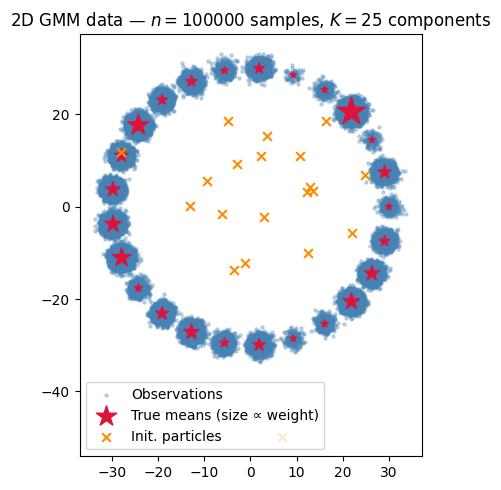

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))

# Scatter plot of observations
X_np = X.cpu().numpy()
ax.scatter(X_np[:, 0], X_np[:, 1], s=5, alpha=0.3, color="steelblue", label="Observations")

# True component means — size proportional to true weight
m_np  = true_means.cpu().numpy()
w_np  = (true_weights / true_weights.sum()).cpu().numpy()   # normalised to sum to 1
m_sizes = 20 + 2000 * w_np                             # range ~ [80, 580]
ax.scatter(m_np[:, 0], m_np[:, 1], s=m_sizes, marker="*",
           color="crimson", zorder=5, label="True means (size ∝ weight)")

# Initial particle positions
p_np = particles.positions.detach().cpu().numpy()
ax.scatter(p_np[:, 0], p_np[:, 1], s=40, marker="x", color="darkorange", zorder=5, label="Init. particles")

ax.set_title(f"2D GMM data — $n={n_samples}$ samples, $K={K_true}$ components")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


## Train / Test Split

We split the $n$ observations into:
- **Train** ($80\%$, $n_{\mathrm{tr}}$ samples) — used to define $\hat{f}_\tau^{n_{\mathrm{tr}}}$ and train the optimizer.
- **Test** ($20\%$, $n_{\mathrm{te}}$ samples) — used to evaluate the **proximity** (generalisation metric).

The **proximity** of $\mu_p$ to the data is the squared $L^2$ discrepancy between the smoothed model and the smoothed empirical measure:
$$
\mathrm{Prox}(\mu_p;\, \mathrm{test})
= \frac{1}{2}\bigl\|\phi_\tau * \mu_p - \hat{f}_\tau^{n_{\mathrm{te}}}\bigr\|_{L^2}^2
= \frac{1}{2}\,\mathbf{a}^\top K\mathbf{a} - \mathbf{a}^\top S_{\mathrm{te}} + C_{\mathrm{te}},
$$
where $S_{\mathrm{te}}$ and $C_{\mathrm{te}}$ are computed on the test set. A small gap between train and test proximity indicates that the solution generalises well and does not over-fit to the training set.


In [6]:
import time

# Hold out 20% of the data as a test set
torch.manual_seed(0)
n_total  = len(X)
n_test   = n_total // 5
perm     = torch.randperm(n_total)
X_train  = X[perm[n_test:]]   # (n_train, 2)
X_test   = X[perm[:n_test]]   # (n_test,  2)

print(f"Train: {len(X_train)} samples  |  Test: {len(X_test)} samples")


Train: 80000 samples  |  Test: 20000 samples


## Hyperparameters & Particle Initialisation

| Symbol | Value | Role |
|--------|-------|------|
| $\kappa$ | `1e-8` | TV regularisation — penalises the total mass $\|\mu\|_{\mathrm{TV}} = \sum_j a_j$ |
| $p$ | `25` | Initial number of particles (equal to $K = 25$) |
| $\tau$ | `1e-2` | Smoothing bandwidth — controls the resolution of the feature map |
| $\eta$ | `5` | CPGD step size for particle **positions** (means) |
| $\eta_w$ | `1e-1` | CPGD step size for raw **weights** $r_i$ in gradient descent |
| $B$ | `1024` | Mini-batch size for stochastic CPGD |
| $T_{\mathrm{full}}$ | `100 000` | Number of full-batch iterations |
| $T_{\mathrm{sto}}$ | `1 000 000` | Number of stochastic iterations |

### Reparametrisation $h(r) = r^2$

The raw parameter $r_i$ is unconstrained. The amplitude is $a_i = h(r_i) = r_i^2$, so:
$$
\frac{\partial \mathcal{L}}{\partial r_i} = h'(r_i)\,J'_\nu(\theta_i) = 2r_i\,J'_\nu(\theta_i),
\qquad
\frac{\partial \mathcal{L}}{\partial \theta_i} = a_i\,\nabla_\theta J'_\nu(\theta_i).
$$
The **CPGD weight update** divides by $h'(r_i)$ to recover the natural descent direction in $a$-space:
$$
r_i \leftarrow r_i - \eta_w\,J'_\nu(\theta_i).
$$
The **CPGD position update** divides by $a_i$ to recover the descent direction for $\theta$:
$$
\theta_i \leftarrow \theta_i - \eta\,\nabla_\theta J'_\nu(\theta_i).
$$

Particles are **randomly initialised** around the origin: positions from $\mathcal{N}(0, 15^2\,I_2)$ (i.e. $\sigma = 0.5 \times R$ where $R = 30$ is the circle radius on which true means lie), raw weights uniformly $1/p$.


In [7]:
# ---- Hyperparameters --------------------------------------------------------
GMM_KAPPA              = 1e-8    # TV regularisation
GMM_N_PARTICLES        = 25      # initial number of particles
GMM_ETA                = 5    # step size: particle positions (means)
GMM_ETA_W              = 1e-1    # step size: raw weights (mirror descent)
GMM_BATCH_SIZE         = 1024     # mini-batch size
GMM_N_ITERATIONS_FULL  = 100_000   # full-batch iterations
GMM_N_ITERATIONS_STO   = 1_000_000  # stochastic iterations
GMM_LOG_INTERVAL       = 200     # log every N iterations

# ---- BLASSO problems --------------------------------------------------------
gmm_problem       = FixedCovGMMBlasso(kappa=GMM_KAPPA, y=X_train, tau=tau)
gmm_problem_test  = FixedCovGMMBlasso(kappa=GMM_KAPPA, y=X_test,  tau=tau)


# ---- Jp analytical property (needed for BD) ---------------------------------
# Monkey-patch Jp into the Evaluation class so BD functions can use ev.Jp.
# J'_nu(theta_i) = kappa + (K a)[i] - S[i]  (BLASSO first-order optimality)
def _Jp(self):
    a = self.particles.amplitudes
    return self.problem.kappa + self.kernel @ a - self.scalar_products

FixedCovGMMBlasso.Evaluation.Jp = cached_property(_Jp)


# ---- Analytical Jp at arbitrary test positions ------------------------------
def compute_jp_gmm(
    problem: FixedCovGMMBlasso,
    particles: FixedCovGMMParticles,
    test_pos: Float[Tensor, "m 2"],
) -> Float[Tensor, " m"]:
    r"""
    Compute J'_\nu(theta) = kappa + (K a)(theta) - S(theta) at each test position.

    K(theta, theta_j)  = N(theta; theta_j, 2*(1+tau^2) I)
    S(theta)           = (1/n) sum_i N(X_i; theta, (1+2*tau^2) I)
    """
    tau   = problem.tau
    d     = 2
    kappa = problem.kappa

    s2k = 2.0 * (1.0 + tau**2)   # kernel bandwidth^2
    s2s = 1.0 + 2.0 * tau**2     # scalar-product bandwidth^2

    with torch.no_grad():
        a     = particles.amplitudes           # (p,)
        theta = particles.positions.data       # (p, 2)

        # K(test_pos[m], theta[j])  ->  (m, p)
        diff_k  = test_pos[:, None, :] - theta[None, :, :]   # (m, p, 2)
        sq_k    = (diff_k**2).sum(-1)                        # (m, p)
        log_K   = -sq_k / (2*s2k) - (d/2)*torch.log(torch.tensor(2*torch.pi*s2k))
        K_test  = torch.exp(log_K)                           # (m, p)

        # S(test_pos[m]) = (1/n) sum_i N(X_i; test_pos[m], s2s I)  ->  (m,)
        diff_s  = test_pos[:, None, :] - problem.y[None, :, :]  # (m, n, 2)
        sq_s    = (diff_s**2).sum(-1)                           # (m, n)
        log_phi = -sq_s / (2*s2s) - (d/2)*torch.log(torch.tensor(2*torch.pi*s2s))
        S_test  = torch.exp(log_phi).mean(-1)                   # (m,)

    return kappa + K_test @ a - S_test   # (m,)


# ---- Particle initialisation ------------------------------------------------
def initialize_gmm_particles(
    n_particles: int,
    position_sigma: float = 1.5,
    seed: Optional[int] = None,
) -> FixedCovGMMParticles:
    """Initialise particles for the fixed-covariance GMM."""
    if seed is not None:
        torch.manual_seed(seed)
    positions = position_sigma * torch.randn(n_particles, 2)
    weights   = (1.0 / n_particles) * torch.ones(n_particles)
    return FixedCovGMMParticles(positions, weights)


print(f"GMM problem initialised:")
print(f"  Training samples : {len(X_train)}")
print(f"  Test samples     : {len(X_test)}")
print(f"  kappa = {GMM_KAPPA},  tau = {tau},  p = {GMM_N_PARTICLES}")
print(f"  eta   = {GMM_ETA},   eta_w = {GMM_ETA_W}")
print(f"  Full-batch iterations : {GMM_N_ITERATIONS_FULL}")
print(f"  Stochastic iterations : {GMM_N_ITERATIONS_STO}  (batch size {GMM_BATCH_SIZE})")


  loss_offset: Monte Carlo estimate (n=80000 > 10000, m=10000)
  loss_offset: Monte Carlo estimate (n=20000 > 10000, m=10000)
GMM problem initialised:
  Training samples : 80000
  Test samples     : 20000
  kappa = 1e-08,  tau = 0.01,  p = 25
  eta   = 5,   eta_w = 0.1
  Full-batch iterations : 100000
  Stochastic iterations : 1000000  (batch size 1024)


## Full-Batch CPGD

**Conic Particle Gradient Descent (CPGD)** performs one gradient step on all $n_{\mathrm{tr}}$ training samples per iteration.

### Update Rules

Given the current particles $\{(r_i, \theta_i)\}_{i=1}^p$ and the full-batch evaluation $J'_\nu(\theta_i) = \kappa + (\mathbf{K}\mathbf{a})_i - S_i$:

$$
r_i \;\leftarrow\; r_i - \eta_w\, J'_\nu(\theta_i),
\qquad
\theta_i \;\leftarrow\; \theta_i - \eta\, \nabla_\theta J'_\nu(\theta_i).
$$

In practice, gradients are retrieved via autograd: `loss.backward()` fills `weights.grad ≈ h'(r_i) J'(θ_i)` and `positions.grad ≈ a_i ∇_θ J'(θ_i)`, which are then normalised by $h'(r_i) = 2r_i$ and $a_i = r_i^2$ respectively.

### Complexity per Step

Each CPGD step requires:
- $\mathbf{K}$ (shape $p \times p$): $\mathcal{O}(p^2)$ pairwise distance evaluations,
- $\mathbf{S}$ (shape $p$): $\mathcal{O}(p\,n)$ distance evaluations between particles and all $n$ training points.

The dominant cost is thus $\mathcal{O}(p\,n)$ per iteration.


In [8]:
@dataclass
class GMMOptimizer:
    """
    Full-batch CPGD for fixed-covariance GMM.

    Parameterisation: h(r) = r^2, so a_i = r_i^2 > 0.

    CPGD update (Euclidean, via autograd gradients):
      - r_i  <- r_i  - alpha * J'_nu(theta_i)          (conic weight step)
      - theta_i <- theta_i - beta * grad_theta J'_nu    (conic position step)

    Using d_loss/dr_i = J'_nu(theta_i) * 2*r_i  and  d_loss/dtheta_i = a_i * grad_theta J'_nu:
      CPGD weight   : alpha * d_loss/dr_i / (2*r_i) = alpha * J'_nu
      CPGD position : beta / a_i * d_loss/dtheta_i   = beta * grad_theta J'_nu
    """
    particles : FixedCovGMMParticles
    problem   : FixedCovGMMBlasso
    beta      : float       # position step
    alpha     : float       # weight (raw) step
    min_weight: float = 1e-6

    def step(self) -> float:
        ev = self.problem(self.particles)
        ev.backward()  # fills .grad and sets gradient_evaluation

        weights   = self.particles.weights
        positions = self.particles.positions
        amplitudes       = self.particles.amplitudes         # r^2
        amplitudes_deriv = self.particles.amplitudes_deriv   # 2*r

        with torch.no_grad():
            safe_deriv = amplitudes_deriv.abs().clamp(min=1e-10)
            safe_amp   = amplitudes.clamp(min=1e-10)

            # CPGD weight step
            grad_w = self.alpha * weights.grad / safe_deriv
            weights.sub_(grad_w)
            weights.clamp_(min=self.min_weight)

            # CPGD position step
            grad_p = self.beta / safe_amp.unsqueeze(-1) * positions.grad
            positions.sub_(grad_p)

        return ev.loss.item()

    def zero_grad(self) -> None:
        self.particles.zero_grad()


# ---- Initialise & train ------------------------------------------------
gmm_particles_full = initialize_gmm_particles(GMM_N_PARTICLES, seed=314, position_sigma= 0.5 * CIRCLE_RADIUS)

gmm_opt_full = GMMOptimizer(
    particles = gmm_particles_full,
    problem   = gmm_problem,
    beta      = GMM_ETA,
    alpha     = GMM_ETA_W,
)

# Metric storage
full_losses = []; full_prox_train = []; full_prox_test = []
full_tv     = []; full_iters     = []; full_times      = []

print("Training Full-Batch CPGD …")
start = time.time()

for it in range(GMM_N_ITERATIONS_FULL):
    gmm_opt_full.zero_grad()
    loss = gmm_opt_full.step()

    if it % GMM_LOG_INTERVAL == 0 or it == GMM_N_ITERATIONS_FULL - 1:
        with torch.no_grad():
            ev_tr = gmm_problem(gmm_particles_full)
            ev_te = gmm_problem_test(gmm_particles_full)
            full_losses.append(ev_tr.loss.item())
            full_prox_train.append(2 * ev_tr.proximity.item())
            full_prox_test.append(2 * ev_te.proximity.item())
            full_tv.append(gmm_particles_full.tv_norm().item())
            full_iters.append(it)
            full_times.append(time.time() - start)
        print(f"Iter {it:5d} | Loss {full_losses[-1]:.6f} | "
              f"Prox(tr) {full_prox_train[-1]:.6f} | Prox(te) {full_prox_test[-1]:.6f} | "
              f"TV {full_tv[-1]:.4f}")

print(f"\nFull-batch done in {full_times[-1]:.2f}s")


Training Full-Batch CPGD …
Iter     0 | Loss 0.043350 | Prox(tr) 0.086701 | Prox(te) 0.087464 | TV 0.0400
Iter   200 | Loss 0.043294 | Prox(tr) 0.086589 | Prox(te) 0.087357 | TV 0.0464
Iter   400 | Loss 0.043216 | Prox(tr) 0.086433 | Prox(te) 0.087211 | TV 0.0642
Iter   600 | Loss 0.043181 | Prox(tr) 0.086361 | Prox(te) 0.087147 | TV 0.0784
Iter   800 | Loss 0.043169 | Prox(tr) 0.086338 | Prox(te) 0.087128 | TV 0.0864
Iter  1000 | Loss 0.043155 | Prox(tr) 0.086309 | Prox(te) 0.087101 | TV 0.0926
Iter  1200 | Loss 0.042887 | Prox(tr) 0.085773 | Prox(te) 0.086572 | TV 0.1289
Iter  1400 | Loss 0.042649 | Prox(tr) 0.085299 | Prox(te) 0.086105 | TV 0.1822
Iter  1600 | Loss 0.042585 | Prox(tr) 0.085170 | Prox(te) 0.085979 | TV 0.2142
Iter  1800 | Loss 0.042572 | Prox(tr) 0.085144 | Prox(te) 0.085955 | TV 0.2291
Iter  2000 | Loss 0.042570 | Prox(tr) 0.085139 | Prox(te) 0.085950 | TV 0.2355
Iter  2200 | Loss 0.042569 | Prox(tr) 0.085137 | Prox(te) 0.085949 | TV 0.2382
Iter  2400 | Loss 0.04256

## Stochastic CPGD — FastPart

At each iteration, a mini-batch $\mathcal{B} \subset \{1,\ldots,n_{\mathrm{tr}}\}$ of size $B$ is drawn uniformly at random. The scalar products are replaced by their mini-batch estimator:
$$
\hat{S}_j^{\mathcal{B}}
= \frac{1}{B}\sum_{i \in \mathcal{B}} \mathcal{N}\!\left(X_i;\,\theta_j,\,(1+2\tau^2)I_2\right)
\approx S_j.
$$
The stochastic dual variable is then $\hat{J}'_{\nu,\mathcal{B}}(\theta_j) = \kappa + (\mathbf{K}\mathbf{a})_j - \hat{S}_j^{\mathcal{B}}$.

### Bias–Variance Trade-off

The mini-batch estimator $\hat{S}^{\mathcal{B}}$ is unbiased ($\mathbb{E}[\hat{S}^{\mathcal{B}}] = S$) but noisy, with variance $\mathcal{O}(1/B)$. Smaller $B$ gives **cheaper iterations** but noisier descent directions; more iterations $T_{\mathrm{sto}} = B^{-1}\,T_{\mathrm{full}}\,n$ are needed to match the number of effective data passes (epochs).

### Complexity per Step

Each stochastic step costs $\mathcal{O}(pB)$ instead of $\mathcal{O}(pn)$, a **speedup factor of $n/B$** per iteration. Here $n/B \approx 78$ (with $n_{\mathrm{tr}} = 80\,000$, $B = 1024$).

> **Epochs**: we track convergence in wall-clock time and also in number of epochs $= \text{iteration} \times B / n_{\mathrm{tr}}$ to fairly compare both methods.


In [9]:
@dataclass
class StochasticGMMOptimizer:
    """Stochastic CPGD for fixed-covariance GMM (mini-batch version)."""
    particles  : FixedCovGMMParticles
    problem    : FixedCovGMMBlasso   # full problem (for eval)
    beta       : float
    alpha      : float
    batch_size : int
    min_weight : float = 1e-6

    def __post_init__(self):
        self.n_train = len(self.problem.y)

    def step(self) -> float:
        idx = torch.randperm(self.n_train)[:self.batch_size]
        mini = FixedCovGMMBlasso(
            kappa=self.problem.kappa,
            y=self.problem.y[idx],
            tau=self.problem.tau,
            skip_offset=True,   # O(1) instead of O(B^2) — safe, gradients unaffected
        )
        ev = mini(self.particles)
        ev.backward()

        weights   = self.particles.weights
        positions = self.particles.positions
        amplitudes       = self.particles.amplitudes
        amplitudes_deriv = self.particles.amplitudes_deriv

        with torch.no_grad():
            safe_deriv = amplitudes_deriv.abs().clamp(min=1e-10)
            safe_amp   = amplitudes.clamp(min=1e-10)

            grad_w = self.alpha * weights.grad / safe_deriv
            weights.sub_(grad_w)
            weights.clamp_(min=self.min_weight)

            grad_p = self.beta / safe_amp.unsqueeze(-1) * positions.grad
            positions.sub_(grad_p)

        return ev.loss.item()

    def zero_grad(self) -> None:
        self.particles.zero_grad()


# ---- Initialise & train ------------------------------------------------
gmm_particles_sto = initialize_gmm_particles(GMM_N_PARTICLES, seed=314, position_sigma= 0.5 * CIRCLE_RADIUS)

gmm_opt_sto = StochasticGMMOptimizer(
    particles  = gmm_particles_sto,
    problem    = gmm_problem,
    beta       = GMM_ETA,
    alpha      = GMM_ETA_W,
    batch_size = GMM_BATCH_SIZE,
)

sto_losses = []; sto_prox_train = []; sto_prox_test = []
sto_tv     = []; sto_iters     = []; sto_times      = []

print(f"Training Stochastic CPGD  |  {GMM_N_ITERATIONS_STO} iters  |  BS={GMM_BATCH_SIZE} …")
start = time.time()

for it in range(GMM_N_ITERATIONS_STO):
    gmm_opt_sto.zero_grad()
    gmm_opt_sto.step()

    if it % GMM_LOG_INTERVAL == 0 or it == GMM_N_ITERATIONS_STO - 1:
        with torch.no_grad():
            ev_tr = gmm_problem(gmm_particles_sto)
            ev_te = gmm_problem_test(gmm_particles_sto)
            sto_losses.append(ev_tr.loss.item())
            sto_prox_train.append(2 * ev_tr.proximity.item())
            sto_prox_test.append(2 * ev_te.proximity.item())
            sto_tv.append(gmm_particles_sto.tv_norm().item())
            sto_iters.append(it)
            sto_times.append(time.time() - start)
        print(f"Iter {it:6d} | Loss {sto_losses[-1]:.6f} | "
              f"Prox(tr) {sto_prox_train[-1]:.6f} | Prox(te) {sto_prox_test[-1]:.6f} | "
              f"TV {sto_tv[-1]:.4f}")

print(f"\nStochastic done in {sto_times[-1]:.2f}s")


Training Stochastic CPGD  |  1000000 iters  |  BS=1024 …
Iter      0 | Loss 0.043350 | Prox(tr) 0.086701 | Prox(te) 0.087464 | TV 0.0400
Iter    200 | Loss 0.043294 | Prox(tr) 0.086588 | Prox(te) 0.087356 | TV 0.0464
Iter    400 | Loss 0.043216 | Prox(tr) 0.086433 | Prox(te) 0.087211 | TV 0.0643
Iter    600 | Loss 0.043180 | Prox(tr) 0.086361 | Prox(te) 0.087147 | TV 0.0786
Iter    800 | Loss 0.043169 | Prox(tr) 0.086338 | Prox(te) 0.087128 | TV 0.0867
Iter   1000 | Loss 0.043153 | Prox(tr) 0.086306 | Prox(te) 0.087098 | TV 0.0932
Iter   1200 | Loss 0.042877 | Prox(tr) 0.085754 | Prox(te) 0.086552 | TV 0.1306
Iter   1400 | Loss 0.042646 | Prox(tr) 0.085291 | Prox(te) 0.086098 | TV 0.1835
Iter   1600 | Loss 0.042584 | Prox(tr) 0.085168 | Prox(te) 0.085977 | TV 0.2147
Iter   1800 | Loss 0.042572 | Prox(tr) 0.085144 | Prox(te) 0.085956 | TV 0.2303
Iter   2000 | Loss 0.042569 | Prox(tr) 0.085139 | Prox(te) 0.085950 | TV 0.2361
Iter   2200 | Loss 0.042569 | Prox(tr) 0.085137 | Prox(te) 0.08

## Convergence Diagnostics — Full-Batch vs Stochastic

The four panels below display:

| Panel | Metric | Interpretation |
|-------|--------|----------------|
| **Top-left** | BLASSO loss $\mathcal{L}$ vs time | Absolute convergence of the objective |
| **Top-right** | $2 \times \mathrm{Prox}$ (train & test) vs time | Data-fit quality; generalisation gap = test − train |
| **Bottom-left** | BLASSO loss vs epochs | Normalises for the data-pass cost; comparable iterations |
| **Bottom-right** | TV norm $\|\mu_p\|_{\mathrm{TV}} = \sum_j a_j$ vs time | Sparsity-inducing effect of $\kappa$ regularisation |

**Key observations to expect:**
- **Full-batch** achieves lower loss per epoch due to exact gradients; **stochastic** is faster per second.
- Train and test proximity curves should track each other closely (no over-fitting) once convergence is reached.
- TV norm typically stabilises as small-weight particles are gradually killed by $\kappa$.


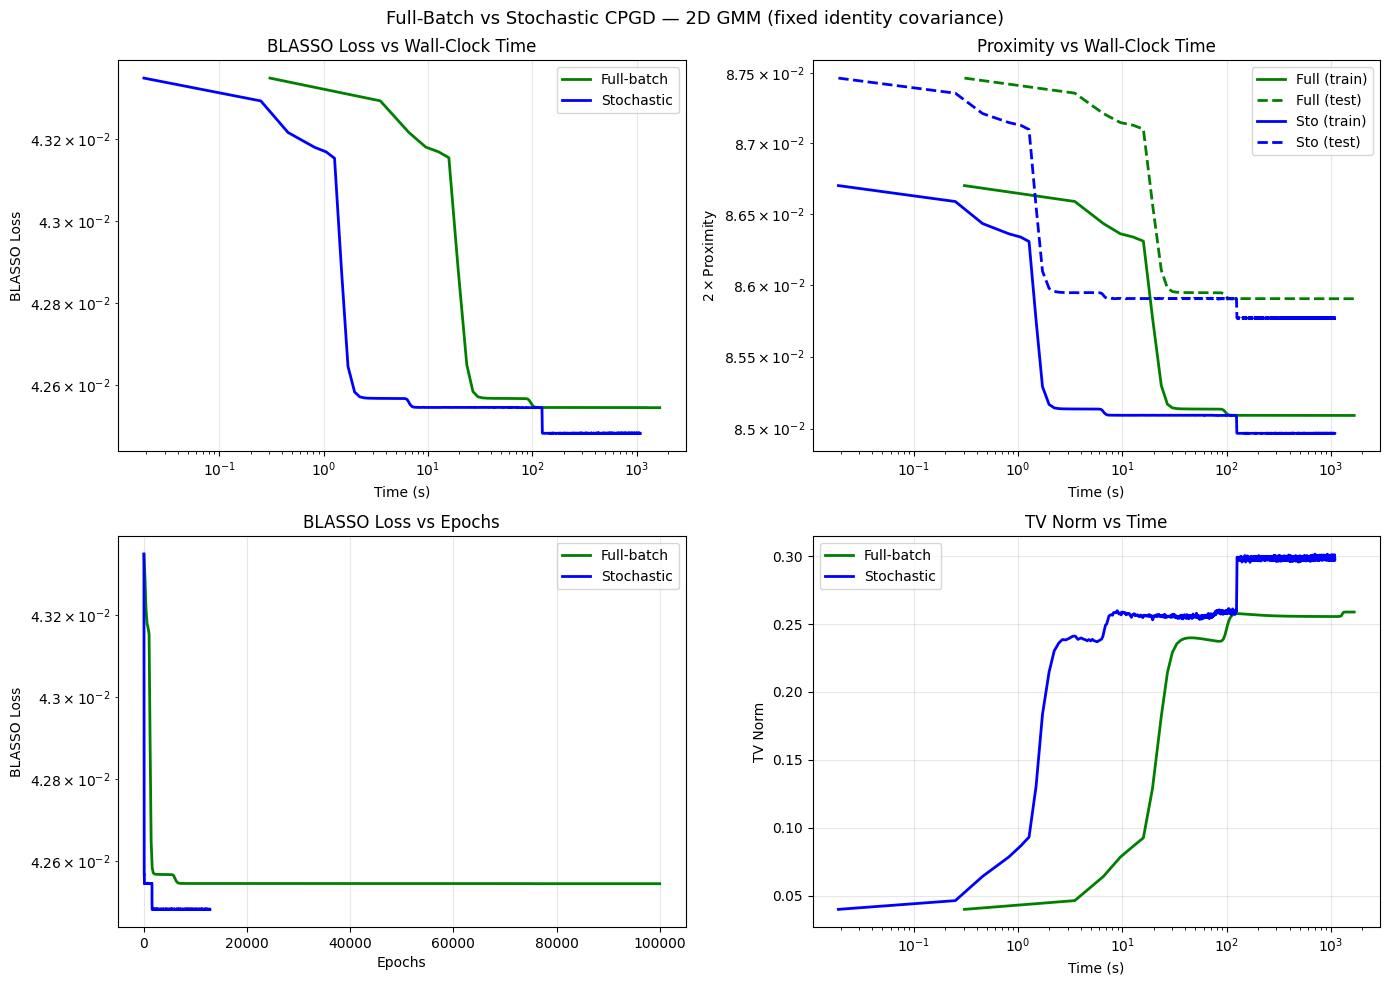


Method                   Prox(tr)     Prox(te)       TV    Time(s)
----------------------------------------------------------------
Full-batch               0.085092     0.085905   0.2588    1667.99
Stochastic               0.084968     0.085769   0.2983    1084.89


In [10]:
sto_epochs  = [it * GMM_BATCH_SIZE / len(X_train) for it in sto_iters]
full_epochs = list(full_iters)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. BLASSO loss vs time
ax = axes[0, 0]
ax.plot(full_times, full_losses, lw=2, color='green', label='Full-batch')
ax.plot(sto_times,  sto_losses,  lw=2, color='blue',  label='Stochastic')
ax.set_xlabel('Time (s)'); ax.set_ylabel('BLASSO Loss')
ax.set_title('BLASSO Loss vs Wall-Clock Time')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_yscale('log'); ax.set_xscale('log')

# 2. Proximity (train & test) vs time
ax = axes[0, 1]
ax.plot(full_times, full_prox_train, lw=2, color='green',                label='Full (train)')
ax.plot(full_times, full_prox_test,  lw=2, color='green', linestyle='--', label='Full (test)')
ax.plot(sto_times,  sto_prox_train,  lw=2, color='blue',                 label='Sto (train)')
ax.plot(sto_times,  sto_prox_test,   lw=2, color='blue',  linestyle='--', label='Sto (test)')
ax.set_xlabel('Time (s)'); ax.set_ylabel(r'$2\times\mathrm{Proximity}$')
ax.set_title('Proximity vs Wall-Clock Time')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_yscale('log'); ax.set_xscale('log')

# 3. Loss vs epochs
ax = axes[1, 0]
ax.plot(full_epochs, full_losses, lw=2, color='green', label='Full-batch')
ax.plot(sto_epochs,  sto_losses,  lw=2, color='blue',  label='Stochastic')
ax.set_xlabel('Epochs'); ax.set_ylabel('BLASSO Loss')
ax.set_title('BLASSO Loss vs Epochs')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_yscale('log')

# 4. TV norm vs time
ax = axes[1, 1]
ax.plot(full_times, full_tv, lw=2, color='green', label='Full-batch')
ax.plot(sto_times,  sto_tv,  lw=2, color='blue',  label='Stochastic')
ax.set_xlabel('Time (s)'); ax.set_ylabel('TV Norm')
ax.set_title('TV Norm vs Time')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_xscale('log')

plt.suptitle('Full-Batch vs Stochastic CPGD — 2D GMM (fixed identity covariance)', fontsize=13)
plt.tight_layout(); plt.show()

print(f"\n{'Method':<20} {'Prox(tr)':>12} {'Prox(te)':>12} {'TV':>8} {'Time(s)':>10}")
print("-"*64)
print(f"{'Full-batch':<20} {full_prox_train[-1]:>12.6f} {full_prox_test[-1]:>12.6f} "
      f"{full_tv[-1]:>8.4f} {full_times[-1]:>10.2f}")
print(f"{'Stochastic':<20} {sto_prox_train[-1]:>12.6f} {sto_prox_test[-1]:>12.6f} "
      f"{sto_tv[-1]:>8.4f} {sto_times[-1]:>10.2f}")


## Birth–Death Process

The Birth–Death (BD) mechanism dynamically adapts the particle count during training.  It is motivated by the first-order optimality condition of the BLASSO: at optimum, $J'_\nu(\theta_j) = 0$ for all support points, so large positive $J'_\nu(\theta_j)$ signals a redundant particle, while a large negative $J'_\nu(\hat\theta)$ at some candidate position $\hat\theta$ signals that adding a new particle there would decrease the loss.

### Death Step

For each particle $j$, compute the normalised score
$$
s_j = \frac{2\,J'_\nu(\theta_j)}{a_j\, K(\theta_j,\theta_j)},
$$
where $K(\theta,\theta) = \frac{1}{4\pi(1+\tau^2)}$ is constant (translation-invariant kernel). The particle with the **largest** $s_{j^*}$ is removed if $s_{j^*} > \tau_{\mathrm{death}}$.

### Birth Step

Sample $n_{\mathrm{test}}$ candidate positions $\hat\theta^{(1)},\ldots,\hat\theta^{(n_{\mathrm{test}})}$ from $\mathcal{N}(0,\sigma_{\mathrm{search}}^2 I_2)$, and evaluate $J'_\nu$ analytically at each (using `compute_jp_gmm`). A new particle is **born** at $\hat\theta^* = \arg\min_m J'_\nu(\hat\theta^{(m)})$ if
$$
J'_\nu(\hat\theta^*) < \tau_{\mathrm{birth}},
$$
with initial amplitude $a_{\mathrm{new}} = |J'_\nu(\hat\theta^*)| / K(\hat\theta^*,\hat\theta^*)$ (i.e. $r_{\mathrm{new}} = \sqrt{a_{\mathrm{new}}}$ since $h(r) = r^2$).

> The threshold $\tau_{\mathrm{birth}}$ is calibrated per regime:
> - **Full-batch**: $\tau_{\mathrm{birth}} = -\kappa$ (negative, equals the TV regularisation parameter).
> - **Stochastic**: $\tau_{\mathrm{birth}} = 100 \cdot \sqrt{2\log B / B}$ (looser, to compensate mini-batch noise).

### BD Schedule

| | Full-batch | Stochastic |
|---|---|---|
| Death delay | 5 000 iters | 20 000 iters |
| Death every | 2 000 iters | 10 000 iters |
| Birth delay | 10 000 iters | 40 000 iters |
| Birth every | 3 000 iters | 20 000 iters |
| $\tau_{\mathrm{birth}}$ | $-\kappa$ | $100\sqrt{2\log B/B}$ |

BD is applied **on the full problem** (even for the stochastic optimizer) to obtain unbiased $J'_\nu$ evaluations for reliable birth/death decisions.


In [11]:
# ============================================================================
# BIRTH–DEATH UTILITY FUNCTIONS (GMM fixed covariance)
# ============================================================================

def bd_remove_gmm(particles: FixedCovGMMParticles, idx: int) -> FixedCovGMMParticles:
    """Return new particles with particle `idx` removed."""
    keep = [i for i in range(len(particles)) if i != idx]
    with torch.no_grad():
        new_pos = particles.positions.data[keep].clone()
        new_w   = particles.weights.data[keep].clone()
    return FixedCovGMMParticles(new_pos, new_w)


def bd_add_gmm(
    particles  : FixedCovGMMParticles,
    new_pos    : Float[Tensor, "2"],
    new_weight : float,
) -> FixedCovGMMParticles:
    """Return new particles with one extra particle appended."""
    with torch.no_grad():
        pos_cat = torch.cat([particles.positions.data, new_pos.unsqueeze(0)], dim=0)
        w_cat   = torch.cat([particles.weights.data,   torch.tensor([new_weight])], dim=0)
    return FixedCovGMMParticles(pos_cat, w_cat)


def death_step_gmm(
    particles : FixedCovGMMParticles,
    problem   : FixedCovGMMBlasso,
    threshold : float,
) -> tuple:
    """
    Remove the particle with the highest score
        s_i = 2 * J'_nu(theta_i) / (a_i * K_self)
    if s_i > threshold.  K_self = N(0; 0, 2*(1+tau^2)*I) is constant.

    Returns (new_particles, died: bool, idx_removed: int or -1).
    """
    with torch.no_grad():
        tau    = problem.tau
        d      = 2
        K_self = float(torch.exp(torch.tensor(
            -(d/2) * torch.log(torch.tensor(2*torch.pi*2*(1+tau**2)))
        )))  # = 1 / (4*pi*(1+tau^2))

        jp = compute_jp_gmm(problem, particles, particles.positions.data)  # (p,)
        a  = particles.amplitudes.data                                      # (p,)
        scores = 2.0 * jp / (a.clamp(min=1e-10) * K_self)

        max_val, max_idx = scores.max(dim=0)
        if max_val.item() > threshold:
            return bd_remove_gmm(particles, max_idx.item()), True, max_idx.item()

    return particles, False, -1


def birth_step_gmm(
    particles      : FixedCovGMMParticles,
    problem        : FixedCovGMMBlasso,
    n_test         : int,
    threshold      : float,
    search_sigma   : float = 2.0,
) -> tuple:
    """
    Sample n_test candidate positions from N(0, search_sigma^2 I).
    Add a particle at argmin J'_nu if min J'_nu < threshold.
    Initial weight: omega_new = |J'_nu(theta_new)| / K_self.

    Returns (new_particles, born: bool, jp_at_new: float).
    """
    with torch.no_grad():
        tau    = problem.tau
        d      = 2
        K_self = float(torch.exp(torch.tensor(
            -(d/2) * torch.log(torch.tensor(2*torch.pi*2*(1+tau**2)))
        )))

        test_pos = search_sigma * torch.randn(n_test, 2)
        jp_test  = compute_jp_gmm(problem, particles, test_pos)  # (n_test,)

        min_val, min_idx = jp_test.min(dim=0)
        if min_val.item() < threshold:
            new_pos    = test_pos[min_idx.item()]
            init_weight = float(min_val.abs().item() / max(K_self, 1e-10))
            init_weight = float(np.sqrt(max(init_weight, 1e-6)))  # convert a=r^2 -> r
            return bd_add_gmm(particles, new_pos, init_weight), True, min_val.item()

    return particles, False, 0.0


print("✓ Birth–death utilities loaded.")
print(f"  K_self (tau={tau}) = 1 / (4*pi*(1+tau^2)) = "
      f"{1/(4*float(torch.pi)*(1+tau**2)):.6f}")


✓ Birth–death utilities loaded.
  K_self (tau=0.01) = 1 / (4*pi*(1+tau^2)) = 0.079570


### Full-Batch CPGD + Birth–Death

We add the BD mechanism to the full-batch CPGD loop.  At each designated iteration, the **full-batch** $J'_\nu$ is used for both gradient descent and birth/death decisions.

**Expected behaviour**: after the initial burn-in phase (death delay = 5 000, birth delay = 10 000), superfluous particles with large $J'_\nu(\theta_j)$ are progressively removed, and new particles may be born near unfit regions. The particle count should converge towards $K = 25$.

> Deaths are typically triggered first (removing weight-zero particles), then births can install new components near unvisited modes.


In [12]:
# Birth–Death schedule (full-batch)
BD_FULL_DEATH_DELAY  = 5_000
BD_FULL_DEATH_EVERY  = 2_000
BD_FULL_BIRTH_DELAY  = 20_000
BD_FULL_BIRTH_EVERY  = 3_000
BD_FULL_N_TEST       = 1000
BD_THRESHOLD_DEATH   = 2.0
_TAU_BIRTH_FULL      = -1 * GMM_KAPPA  # negative multiple of kappa seems to work well in practice
BD_THRESHOLD_BIRTH_FULL = _TAU_BIRTH_FULL 

gmm_particles_full_bd = initialize_gmm_particles(GMM_N_PARTICLES, seed=314, position_sigma= 0.5 * CIRCLE_RADIUS)

def make_full_gmm_opt(p):
    return GMMOptimizer(particles=p, problem=gmm_problem,
                        beta=GMM_ETA, alpha=GMM_ETA_W)

gmm_opt_full_bd = make_full_gmm_opt(gmm_particles_full_bd)

bd_full_losses = []; bd_full_prox_tr = []; bd_full_prox_te = []
bd_full_tv     = []; bd_full_np      = []; bd_full_iters   = []
bd_full_times  = []; bd_full_deaths  = []; bd_full_births  = []

print("Training Full-Batch CPGD + Birth–Death …")
print(f"  tau_death={BD_THRESHOLD_DEATH}  tau_birth=BD_THRESHOLD_BIRTH_FULL={BD_THRESHOLD_BIRTH_FULL:.6f}")
start_bd_full = time.time()

for it in range(GMM_N_ITERATIONS_FULL):
    p = gmm_opt_full_bd.particles

    # CPGD step
    gmm_opt_full_bd.zero_grad()
    gmm_opt_full_bd.step()

    # Death
    if it >= BD_FULL_DEATH_DELAY and it % BD_FULL_DEATH_EVERY == 0 and len(p) > 1:
        new_p, died, _ = death_step_gmm(p, gmm_problem, BD_THRESHOLD_DEATH)
        if died:
            gmm_opt_full_bd = make_full_gmm_opt(new_p)
            bd_full_deaths.append((it, len(new_p)))

    # Birth
    if (it >= BD_FULL_BIRTH_DELAY and it % BD_FULL_BIRTH_EVERY == 0) and (it <= GMM_N_ITERATIONS_FULL- BD_FULL_BIRTH_DELAY):
        p = gmm_opt_full_bd.particles
        new_p, born, _ = birth_step_gmm(
            p, gmm_problem, BD_FULL_N_TEST, BD_THRESHOLD_BIRTH_FULL, search_sigma= 0.5 * CIRCLE_RADIUS)
        if born:
            gmm_opt_full_bd = make_full_gmm_opt(new_p)
            bd_full_births.append((it, len(new_p)))

    # Logging
    if it % GMM_LOG_INTERVAL == 0 or it == GMM_N_ITERATIONS_FULL - 1:
        p = gmm_opt_full_bd.particles
        with torch.no_grad():
            ev_tr = gmm_problem(p);      ev_te = gmm_problem_test(p)
            bd_full_losses.append(ev_tr.loss.item())
            bd_full_prox_tr.append(2 * ev_tr.proximity.item())
            bd_full_prox_te.append(2 * ev_te.proximity.item())
            bd_full_tv.append(p.tv_norm().item())
            bd_full_np.append(len(p))
            bd_full_iters.append(it)
            bd_full_times.append(time.time() - start_bd_full)
        print(f"Iter {it:5d} | Loss {bd_full_losses[-1]:.6f} | "
              f"Prox(tr) {bd_full_prox_tr[-1]:.6f} | TV {bd_full_tv[-1]:.4f} | "
              f"p={len(p)} | births={len(bd_full_births)} deaths={len(bd_full_deaths)}")

print(f"\nFull-BD done in {bd_full_times[-1]:.2f}s  |  "
      f"Deaths: {len(bd_full_deaths)}  Births: {len(bd_full_births)}")


Training Full-Batch CPGD + Birth–Death …
  tau_death=2.0  tau_birth=BD_THRESHOLD_BIRTH_FULL=-0.000000
Iter     0 | Loss 0.043350 | Prox(tr) 0.086701 | TV 0.0400 | p=25 | births=0 deaths=0
Iter   200 | Loss 0.043294 | Prox(tr) 0.086589 | TV 0.0464 | p=25 | births=0 deaths=0
Iter   400 | Loss 0.043216 | Prox(tr) 0.086433 | TV 0.0642 | p=25 | births=0 deaths=0
Iter   600 | Loss 0.043181 | Prox(tr) 0.086361 | TV 0.0784 | p=25 | births=0 deaths=0
Iter   800 | Loss 0.043169 | Prox(tr) 0.086338 | TV 0.0864 | p=25 | births=0 deaths=0
Iter  1000 | Loss 0.043155 | Prox(tr) 0.086309 | TV 0.0926 | p=25 | births=0 deaths=0
Iter  1200 | Loss 0.042887 | Prox(tr) 0.085773 | TV 0.1289 | p=25 | births=0 deaths=0
Iter  1400 | Loss 0.042649 | Prox(tr) 0.085299 | TV 0.1822 | p=25 | births=0 deaths=0
Iter  1600 | Loss 0.042585 | Prox(tr) 0.085170 | TV 0.2142 | p=25 | births=0 deaths=0
Iter  1800 | Loss 0.042572 | Prox(tr) 0.085144 | TV 0.2291 | p=25 | births=0 deaths=0
Iter  2000 | Loss 0.042570 | Prox(tr) 

/var/folders/qz/tf99qztd2jx62vrtddtkr1700000gq/T/ipykernel_53794/635603654.py:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  K_self = float(torch.exp(torch.tensor(


Iter  6000 | Loss 0.042559 | Prox(tr) 0.085118 | TV 0.2417 | p=24 | births=0 deaths=1
Iter  6200 | Loss 0.042553 | Prox(tr) 0.085107 | TV 0.2456 | p=24 | births=0 deaths=1
Iter  6400 | Loss 0.042550 | Prox(tr) 0.085100 | TV 0.2493 | p=24 | births=0 deaths=1
Iter  6600 | Loss 0.042548 | Prox(tr) 0.085096 | TV 0.2522 | p=24 | births=0 deaths=1
Iter  6800 | Loss 0.042547 | Prox(tr) 0.085094 | TV 0.2543 | p=24 | births=0 deaths=1
Iter  7000 | Loss 0.042547 | Prox(tr) 0.085093 | TV 0.2557 | p=24 | births=0 deaths=1
Iter  7200 | Loss 0.042546 | Prox(tr) 0.085093 | TV 0.2565 | p=24 | births=0 deaths=1
Iter  7400 | Loss 0.042546 | Prox(tr) 0.085093 | TV 0.2570 | p=24 | births=0 deaths=1
Iter  7600 | Loss 0.042546 | Prox(tr) 0.085093 | TV 0.2573 | p=24 | births=0 deaths=1
Iter  7800 | Loss 0.042546 | Prox(tr) 0.085093 | TV 0.2575 | p=24 | births=0 deaths=1
Iter  8000 | Loss 0.042546 | Prox(tr) 0.085092 | TV 0.2574 | p=23 | births=0 deaths=2
Iter  8200 | Loss 0.042546 | Prox(tr) 0.085092 | TV 0.

/var/folders/qz/tf99qztd2jx62vrtddtkr1700000gq/T/ipykernel_53794/635603654.py:73: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  K_self = float(torch.exp(torch.tensor(


Iter 21000 | Loss 0.042362 | Prox(tr) 0.084725 | TV 0.3237 | p=18 | births=1 deaths=8
Iter 21200 | Loss 0.040848 | Prox(tr) 0.081696 | TV 0.4123 | p=18 | births=1 deaths=8
Iter 21400 | Loss 0.040723 | Prox(tr) 0.081445 | TV 0.4555 | p=18 | births=1 deaths=8
Iter 21600 | Loss 0.040714 | Prox(tr) 0.081429 | TV 0.4668 | p=18 | births=1 deaths=8
Iter 21800 | Loss 0.040714 | Prox(tr) 0.081428 | TV 0.4695 | p=18 | births=1 deaths=8
Iter 22000 | Loss 0.040714 | Prox(tr) 0.081428 | TV 0.4701 | p=17 | births=1 deaths=9
Iter 22200 | Loss 0.040714 | Prox(tr) 0.081428 | TV 0.4702 | p=17 | births=1 deaths=9
Iter 22400 | Loss 0.040714 | Prox(tr) 0.081428 | TV 0.4702 | p=17 | births=1 deaths=9
Iter 22600 | Loss 0.040714 | Prox(tr) 0.081428 | TV 0.4702 | p=17 | births=1 deaths=9
Iter 22800 | Loss 0.040714 | Prox(tr) 0.081428 | TV 0.4702 | p=17 | births=1 deaths=9
Iter 23000 | Loss 0.040714 | Prox(tr) 0.081428 | TV 0.4702 | p=17 | births=1 deaths=9
Iter 23200 | Loss 0.040714 | Prox(tr) 0.081428 | TV 0.

### Stochastic CPGD (FastPart) + Birth–Death


In [13]:
# Birth–Death schedule (stochastic)
BD_STO_DEATH_DELAY  = 20_000
BD_STO_DEATH_EVERY  = 10_000
BD_STO_BIRTH_DELAY  = 100_000
BD_STO_BIRTH_EVERY  = 20_000
BD_STO_N_TEST       = 1_000
_TAU_BIRTH_STO      = 100
BD_THRESHOLD_BIRTH_STO = _TAU_BIRTH_STO * np.sqrt(
    2 * np.log(GMM_BATCH_SIZE) / GMM_BATCH_SIZE
)

gmm_particles_sto_bd = initialize_gmm_particles(GMM_N_PARTICLES, seed=314)

def make_sto_gmm_opt(p):
    return StochasticGMMOptimizer(
        particles=p, problem=gmm_problem,
        beta=GMM_ETA, alpha=GMM_ETA_W, batch_size=GMM_BATCH_SIZE)

gmm_opt_sto_bd = make_sto_gmm_opt(gmm_particles_sto_bd)

bd_sto_losses  = []; bd_sto_prox_tr = []; bd_sto_prox_te = []
bd_sto_tv      = []; bd_sto_np      = []; bd_sto_iters   = []
bd_sto_times   = []; bd_sto_deaths  = []; bd_sto_births  = []

print("Training Stochastic CPGD + Birth–Death …")
print(f"  tau_birth=5, threshold={BD_THRESHOLD_BIRTH_STO:.6f}  "
      f"(= 5*sqrt(2*log({GMM_BATCH_SIZE})/{GMM_BATCH_SIZE}))")
start_bd_sto = time.time()

for it in range(GMM_N_ITERATIONS_STO):
    p = gmm_opt_sto_bd.particles

    # Stochastic CPGD step
    gmm_opt_sto_bd.zero_grad()
    gmm_opt_sto_bd.step()

    # Death (use full problem for reliable Jp)
    if it >= BD_STO_DEATH_DELAY and it % BD_STO_DEATH_EVERY == 0 and len(p) > 1:
        new_p, died, _ = death_step_gmm(p, gmm_problem, BD_THRESHOLD_DEATH)
        if died:
            gmm_opt_sto_bd = make_sto_gmm_opt(new_p)
            bd_sto_deaths.append((it, len(new_p)))

    # Birth (use full problem for reliable Jp)
    if (it >= BD_STO_BIRTH_DELAY and it % BD_STO_BIRTH_EVERY == 0) and (it <= GMM_N_ITERATIONS_STO - BD_STO_BIRTH_DELAY):
        p = gmm_opt_sto_bd.particles
        new_p, born, _ = birth_step_gmm(
            p, gmm_problem, BD_STO_N_TEST, BD_THRESHOLD_BIRTH_STO, search_sigma= 0.5 * CIRCLE_RADIUS)
        if born:
            gmm_opt_sto_bd = make_sto_gmm_opt(new_p)
            bd_sto_births.append((it, len(new_p)))

    # Logging
    if it % GMM_LOG_INTERVAL == 0 or it == GMM_N_ITERATIONS_STO - 1:
        p = gmm_opt_sto_bd.particles
        with torch.no_grad():
            ev_tr = gmm_problem(p);      ev_te = gmm_problem_test(p)
            bd_sto_losses.append(ev_tr.loss.item())
            bd_sto_prox_tr.append(2 * ev_tr.proximity.item())
            bd_sto_prox_te.append(2 * ev_te.proximity.item())
            bd_sto_tv.append(p.tv_norm().item())
            bd_sto_np.append(len(p))
            bd_sto_iters.append(it)
            bd_sto_times.append(time.time() - start_bd_sto)
        print(f"Iter {it:6d} | Loss {bd_sto_losses[-1]:.6f} | "
              f"Prox(tr) {bd_sto_prox_tr[-1]:.6f} | TV {bd_sto_tv[-1]:.4f} | "
              f"p={len(p)} | births={len(bd_sto_births)} deaths={len(bd_sto_deaths)}")

print(f"\nStochastic-BD done in {bd_sto_times[-1]:.2f}s  |  "
      f"Deaths: {len(bd_sto_deaths)}  Births: {len(bd_sto_births)}")


Training Stochastic CPGD + Birth–Death …
  tau_birth=5, threshold=11.635304  (= 5*sqrt(2*log(1024)/1024))
Iter      0 | Loss 0.043369 | Prox(tr) 0.086738 | TV 0.0398 | p=25 | births=0 deaths=0
Iter    200 | Loss 0.043355 | Prox(tr) 0.086710 | TV 0.0201 | p=25 | births=0 deaths=0
Iter    400 | Loss 0.043352 | Prox(tr) 0.086705 | TV 0.0129 | p=25 | births=0 deaths=0
Iter    600 | Loss 0.043352 | Prox(tr) 0.086704 | TV 0.0092 | p=25 | births=0 deaths=0
Iter    800 | Loss 0.043351 | Prox(tr) 0.086703 | TV 0.0070 | p=25 | births=0 deaths=0
Iter   1000 | Loss 0.043351 | Prox(tr) 0.086703 | TV 0.0056 | p=25 | births=0 deaths=0
Iter   1200 | Loss 0.043351 | Prox(tr) 0.086703 | TV 0.0046 | p=25 | births=0 deaths=0
Iter   1400 | Loss 0.043351 | Prox(tr) 0.086702 | TV 0.0039 | p=25 | births=0 deaths=0
Iter   1600 | Loss 0.043351 | Prox(tr) 0.086702 | TV 0.0033 | p=25 | births=0 deaths=0
Iter   1800 | Loss 0.043351 | Prox(tr) 0.086702 | TV 0.0029 | p=25 | births=0 deaths=0
Iter   2000 | Loss 0.043

/var/folders/qz/tf99qztd2jx62vrtddtkr1700000gq/T/ipykernel_53794/635603654.py:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  K_self = float(torch.exp(torch.tensor(


Iter  20000 | Loss 0.043351 | Prox(tr) 0.086702 | TV 0.0001 | p=24 | births=0 deaths=1
Iter  20200 | Loss 0.043351 | Prox(tr) 0.086702 | TV 0.0001 | p=24 | births=0 deaths=1
Iter  20400 | Loss 0.043351 | Prox(tr) 0.086702 | TV 0.0001 | p=24 | births=0 deaths=1
Iter  20600 | Loss 0.043351 | Prox(tr) 0.086702 | TV 0.0001 | p=24 | births=0 deaths=1
Iter  20800 | Loss 0.043351 | Prox(tr) 0.086702 | TV 0.0001 | p=24 | births=0 deaths=1
Iter  21000 | Loss 0.043351 | Prox(tr) 0.086702 | TV 0.0001 | p=24 | births=0 deaths=1
Iter  21200 | Loss 0.043351 | Prox(tr) 0.086702 | TV 0.0001 | p=24 | births=0 deaths=1
Iter  21400 | Loss 0.043351 | Prox(tr) 0.086702 | TV 0.0001 | p=24 | births=0 deaths=1
Iter  21600 | Loss 0.043351 | Prox(tr) 0.086702 | TV 0.0001 | p=24 | births=0 deaths=1
Iter  21800 | Loss 0.043351 | Prox(tr) 0.086702 | TV 0.0001 | p=24 | births=0 deaths=1
Iter  22000 | Loss 0.043351 | Prox(tr) 0.086702 | TV 0.0001 | p=24 | births=0 deaths=1
Iter  22200 | Loss 0.043351 | Prox(tr) 0.08

/var/folders/qz/tf99qztd2jx62vrtddtkr1700000gq/T/ipykernel_53794/635603654.py:73: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  K_self = float(torch.exp(torch.tensor(


Iter 100000 | Loss 0.042715 | Prox(tr) 0.085430 | TV 0.1264 | p=17 | births=1 deaths=9
Iter 100200 | Loss 0.041549 | Prox(tr) 0.083099 | TV 0.1868 | p=17 | births=1 deaths=9
Iter 100400 | Loss 0.041521 | Prox(tr) 0.083042 | TV 0.2076 | p=17 | births=1 deaths=9
Iter 100600 | Loss 0.041519 | Prox(tr) 0.083038 | TV 0.2128 | p=17 | births=1 deaths=9
Iter 100800 | Loss 0.041519 | Prox(tr) 0.083038 | TV 0.2135 | p=17 | births=1 deaths=9
Iter 101000 | Loss 0.041519 | Prox(tr) 0.083039 | TV 0.2139 | p=17 | births=1 deaths=9
Iter 101200 | Loss 0.041519 | Prox(tr) 0.083038 | TV 0.2148 | p=17 | births=1 deaths=9
Iter 101400 | Loss 0.041519 | Prox(tr) 0.083038 | TV 0.2154 | p=17 | births=1 deaths=9
Iter 101600 | Loss 0.041519 | Prox(tr) 0.083038 | TV 0.2139 | p=17 | births=1 deaths=9
Iter 101800 | Loss 0.041519 | Prox(tr) 0.083038 | TV 0.2141 | p=17 | births=1 deaths=9
Iter 102000 | Loss 0.041519 | Prox(tr) 0.083038 | TV 0.2142 | p=17 | births=1 deaths=9
Iter 102200 | Loss 0.041519 | Prox(tr) 0.08

### 4-Way Comparison: Standard vs Birth–Death

We compare four methods on six diagnostic panels:

| Panel | Metric | What to look for |
|-------|--------|-----------------|
| **Loss vs time** | $\mathcal{L}$ | BD methods should reach lower loss by trimming superfluous particles |
| **Test proximity vs time** | $\mathrm{Prox}_{\mathrm{te}}$ | Validates generalisation; BD may help if excess particles were over-fitting |
| **TV norm vs time** | $\|\mu_p\|_{\mathrm{TV}}$ | BD removes mass → lower TV; standard CPGD may keep many small-weight particles |
| **Particle count vs time** | $p(t)$ | Should converge towards $K = 25$ with BD |
| **Full-batch BD timeline** | births ▲ / deaths ▼ | Visualises the adaptation dynamics in the full-batch regime |
| **Stochastic BD timeline** | births ▲ / deaths ▼ | Same in the stochastic regime |

The summary table reports final values for all four methods.


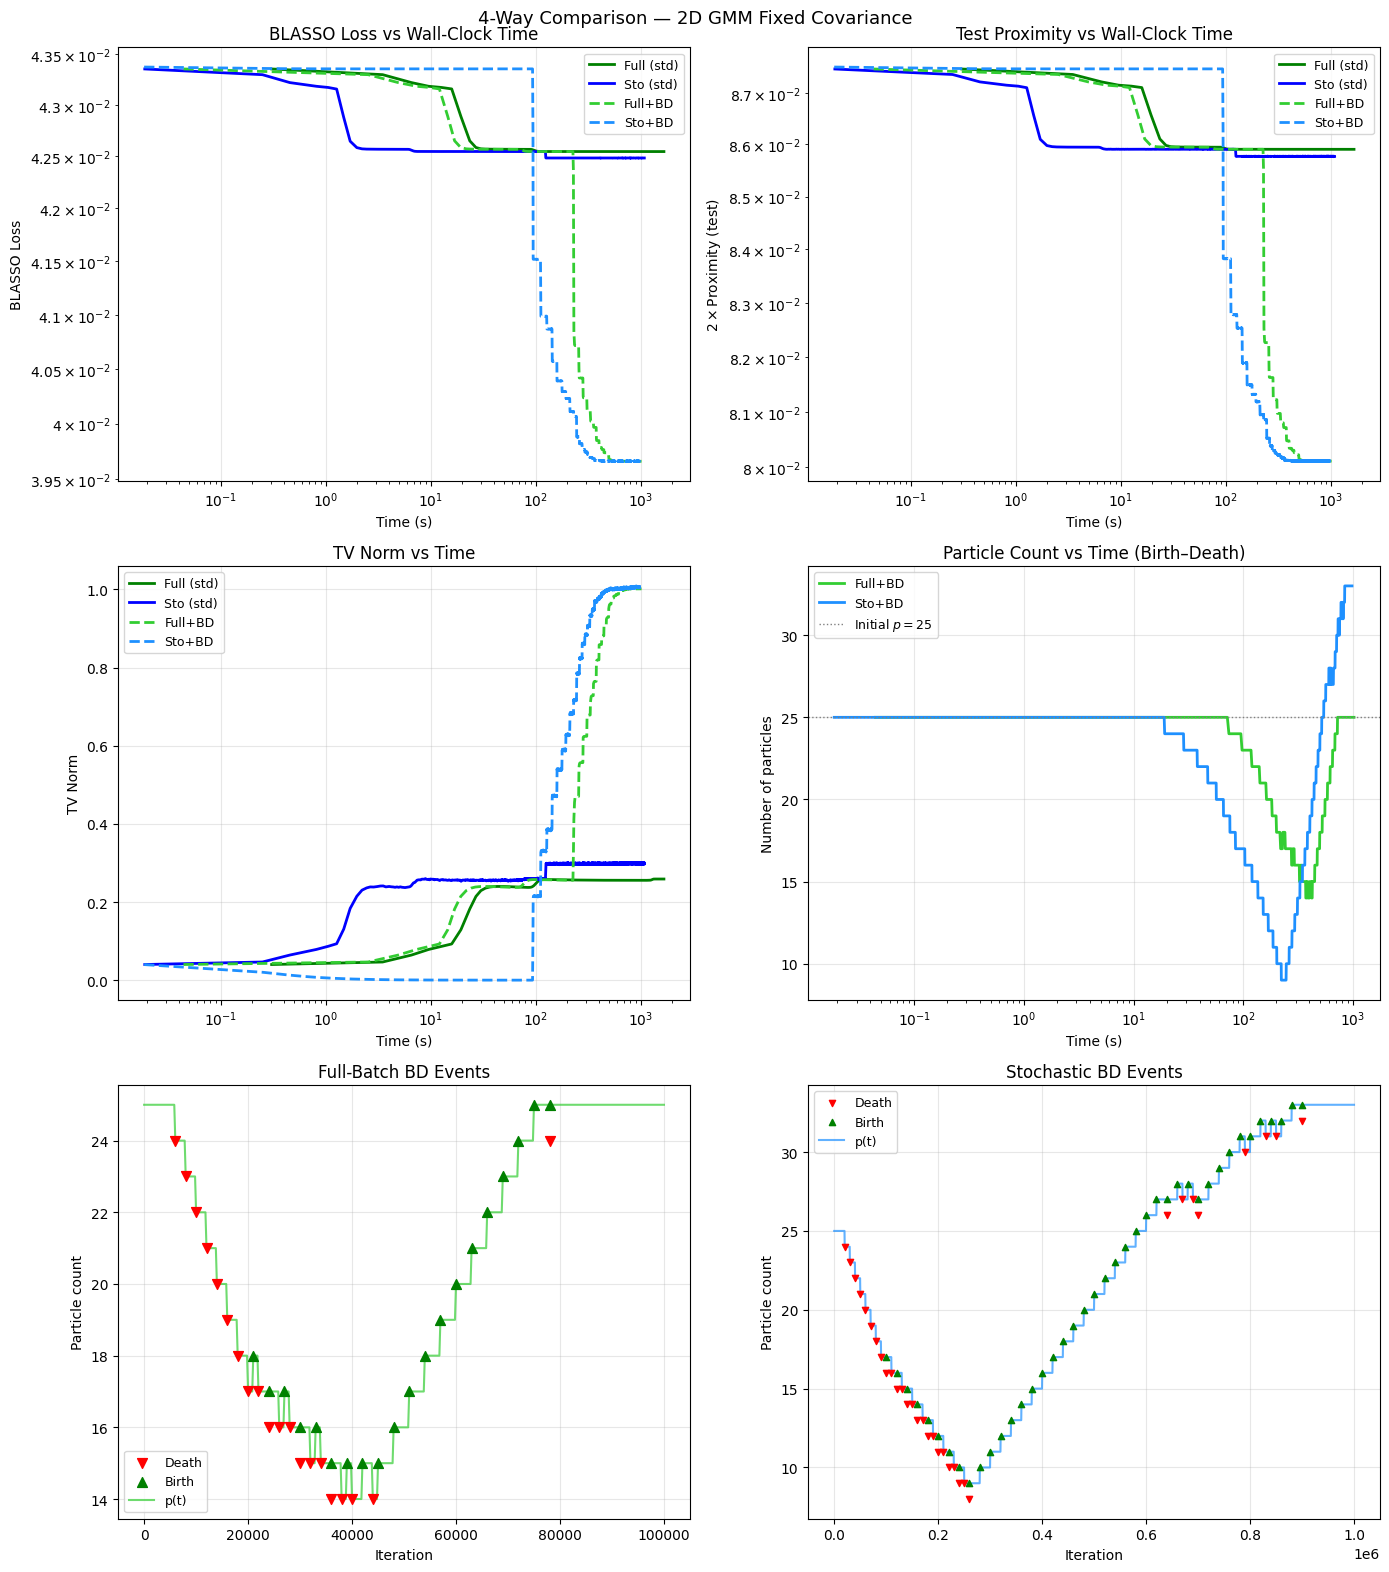


SUMMARY
Method                     Prox(tr)     Prox(te)       TV  p_final    Time(s)  Deaths  Births
--------------------------------------------------------------------------------
Full-batch                 0.085092     0.085905   0.2588       25    1667.99       0       0
Stochastic                 0.084968     0.085769   0.2983       25    1084.89       0       0
Full-batch+BD              0.079320     0.080113   1.0015       25    1020.60      20      20
Stochastic+BD              0.079320     0.080114   1.0058       33     978.39      33      41


In [14]:
fig, axes = plt.subplots(3, 2, figsize=(14, 16))

# 1. BLASSO Loss vs time
ax = axes[0, 0]
ax.plot(full_times,    full_losses,   lw=2, color='green',       label='Full (std)')
ax.plot(sto_times,     sto_losses,    lw=2, color='blue',        label='Sto (std)')
ax.plot(bd_full_times, bd_full_losses,lw=2, color='limegreen',   label='Full+BD', linestyle='--')
ax.plot(bd_sto_times,  bd_sto_losses, lw=2, color='dodgerblue',  label='Sto+BD',  linestyle='--')
ax.set_xlabel('Time (s)'); ax.set_ylabel('BLASSO Loss')
ax.set_title('BLASSO Loss vs Wall-Clock Time')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_yscale('log'); ax.set_xscale('log')

# 2. Test proximity vs time
ax = axes[0, 1]
ax.plot(full_times,    full_prox_test,    lw=2, color='green',      label='Full (std)')
ax.plot(sto_times,     sto_prox_test,     lw=2, color='blue',       label='Sto (std)')
ax.plot(bd_full_times, bd_full_prox_te,   lw=2, color='limegreen',  label='Full+BD', linestyle='--')
ax.plot(bd_sto_times,  bd_sto_prox_te,    lw=2, color='dodgerblue', label='Sto+BD',  linestyle='--')
ax.set_xlabel('Time (s)'); ax.set_ylabel(r'$2\times\mathrm{Proximity}$ (test)')
ax.set_title('Test Proximity vs Wall-Clock Time')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_yscale('log'); ax.set_xscale('log')

# 3. TV norm vs time
ax = axes[1, 0]
ax.plot(full_times,    full_tv,    lw=2, color='green',      label='Full (std)')
ax.plot(sto_times,     sto_tv,     lw=2, color='blue',       label='Sto (std)')
ax.plot(bd_full_times, bd_full_tv, lw=2, color='limegreen',  label='Full+BD', linestyle='--')
ax.plot(bd_sto_times,  bd_sto_tv,  lw=2, color='dodgerblue', label='Sto+BD',  linestyle='--')
ax.set_xlabel('Time (s)'); ax.set_ylabel('TV Norm')
ax.set_title('TV Norm vs Time')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_xscale('log')

# 4. Particle count vs time (BD only)
ax = axes[1, 1]
ax.plot(bd_full_times, bd_full_np, lw=2, color='limegreen',  label='Full+BD')
ax.plot(bd_sto_times,  bd_sto_np,  lw=2, color='dodgerblue', label='Sto+BD')
ax.axhline(GMM_N_PARTICLES, color='grey', linestyle=':', lw=1,
           label=f'Initial $p={GMM_N_PARTICLES}$')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Number of particles')
ax.set_title('Particle Count vs Time (Birth–Death)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_xscale('log')

# 5. BD events — full-batch
ax = axes[2, 0]
if bd_full_deaths:
    d_steps, d_ps = zip(*bd_full_deaths)
    ax.scatter(d_steps, d_ps, color='red',   marker='v', s=50, label='Death', zorder=3)
if bd_full_births:
    b_steps, b_ps = zip(*bd_full_births)
    ax.scatter(b_steps, b_ps, color='green', marker='^', s=50, label='Birth', zorder=3)
ax.plot(bd_full_iters, bd_full_np, lw=1.5, color='limegreen', alpha=0.7, label='p(t)')
ax.set_xlabel('Iteration'); ax.set_ylabel('Particle count')
ax.set_title('Full-Batch BD Events'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# 6. BD events — stochastic
ax = axes[2, 1]
if bd_sto_deaths:
    d_steps, d_ps = zip(*bd_sto_deaths)
    ax.scatter(d_steps, d_ps, color='red',   marker='v', s=20, label='Death', zorder=3)
if bd_sto_births:
    b_steps, b_ps = zip(*bd_sto_births)
    ax.scatter(b_steps, b_ps, color='green', marker='^', s=20, label='Birth', zorder=3)
ax.plot(bd_sto_iters, bd_sto_np, lw=1.5, color='dodgerblue', alpha=0.7, label='p(t)')
ax.set_xlabel('Iteration'); ax.set_ylabel('Particle count')
ax.set_title('Stochastic BD Events'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.suptitle('4-Way Comparison — 2D GMM Fixed Covariance', fontsize=13)
plt.tight_layout(); plt.show()

# Summary table
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
header = f"{'Method':<22} {'Prox(tr)':>12} {'Prox(te)':>12} {'TV':>8} {'p_final':>8} {'Time(s)':>10} {'Deaths':>7} {'Births':>7}"
print(header); print("-"*80)
rows = [
    ("Full-batch",    full_prox_train[-1],    full_prox_test[-1],    full_tv[-1],    GMM_N_PARTICLES, full_times[-1],    0, 0),
    ("Stochastic",    sto_prox_train[-1],     sto_prox_test[-1],     sto_tv[-1],     GMM_N_PARTICLES, sto_times[-1],     0, 0),
    ("Full-batch+BD", bd_full_prox_tr[-1],    bd_full_prox_te[-1],   bd_full_tv[-1], bd_full_np[-1],  bd_full_times[-1], len(bd_full_deaths), len(bd_full_births)),
    ("Stochastic+BD", bd_sto_prox_tr[-1],     bd_sto_prox_te[-1],    bd_sto_tv[-1],  bd_sto_np[-1],   bd_sto_times[-1],  len(bd_sto_deaths),  len(bd_sto_births)),
]
for r in rows:
    print(f"{r[0]:<22} {r[1]:>12.6f} {r[2]:>12.6f} {r[3]:>8.4f} {r[4]:>8d} {r[5]:>10.2f} {r[6]:>7d} {r[7]:>7d}")
print("="*80)


### Final Particle Positions in $\mathbb{R}^2$

Each subplot shows the positions $\{\theta_j\}$ of the learned particles overlaid on the training data and the **true component means** $\{\theta_k^0\}$ (red stars). Marker sizes are proportional to the amplitude $a_j = r_j^2$.

**Ideal outcome**: after convergence, the particles with significant weight should concentrate near the true means $\theta_k^0$, recovering the support of $f^0$. Particles with very small $a_j$ (leftover ghost particles) are visible as tiny dots and represent the residual cost of over-parametrisation without BD.

> With Birth–Death, the number of significant particles is expected to be much closer to $K = 25$, and their positions more accurately centred on the true means.


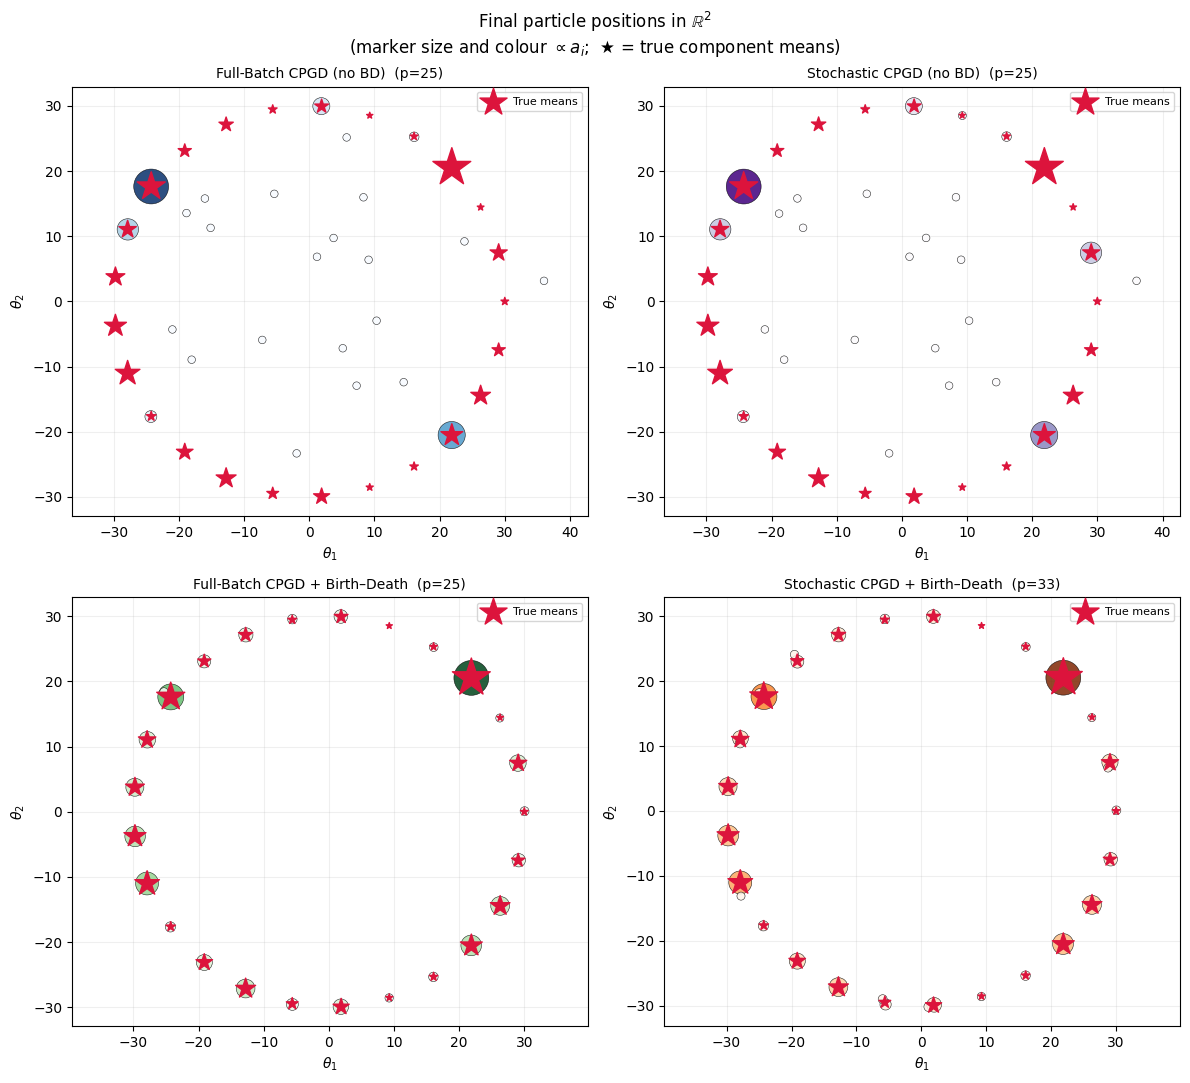

In [15]:
# ============================================================
# Final particle positions — 4-panel scatter in R^2
# ============================================================
_configs = [
    (gmm_opt_full.particles,    'Full-Batch CPGD (no BD)',       'Blues'),
    (gmm_opt_sto.particles,     'Stochastic CPGD (no BD)',       'Purples'),
    (gmm_opt_full_bd.particles, 'Full-Batch CPGD + Birth–Death', 'Greens'),
    (gmm_opt_sto_bd.particles,  'Stochastic CPGD + Birth–Death', 'Oranges'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 11))

for ax, (parts, title, cmap) in zip(axes.flat, _configs):
    with torch.no_grad():
        pos = parts.positions.detach().cpu().numpy()   # (p, 2)
        a   = parts.amplitudes.detach().cpu().numpy()  # a = r^2

    sizes = 30 + 600 * a / (a.max() + 1e-12)

    sc = ax.scatter(pos[:, 0], pos[:, 1],
                    s=sizes, c=a, cmap=cmap,
                    vmin=0., vmax=a.max(),
                    alpha=0.85, edgecolors='k', linewidths=0.4, zorder=3)
    #cb = plt.colorbar(sc, ax=ax, pad=0.02, shrink=0.85)
    #cb.set_label(r'$a_i = r_i^2$', fontsize=9)

    # True component means
    m = true_means.numpy()
    w_np = (true_weights / true_weights.sum()).detach().cpu().numpy()
    m_sizes = 20 + 800 * w_np / (w_np.max() + 1e-12)
    ax.scatter(m[:, 0], m[:, 1], s=m_sizes, marker='*', alpha=1,
               color='crimson', zorder=6, label='True means')

    # Data cloud (light background)
    #ax.scatter(X_train[:, 0].numpy(), X_train[:, 1].numpy(),
    #           s=1, alpha=0.008, color='steelblue', zorder=1)

    ax.set_title(f"{title}  (p={len(parts)})", fontsize=10)
    ax.set_xlabel(r'$\theta_1$'); ax.set_ylabel(r'$\theta_2$')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2)
    ax.set_aspect('equal', adjustable='datalim')

plt.suptitle(
    r'Final particle positions in $\mathbb{R}^2$'
    '\n'
    r'(marker size and colour $\propto a_i$;  $\bigstar$ = true component means)',
    fontsize=12
)
plt.tight_layout(); plt.show()


## Summary and Conclusions

### What was studied

This notebook implemented the full BLASSO–CPGD pipeline for a **2D Gaussian mixture model with fixed identity covariance** ($K = 25$ components on a circle of radius $R = 30$), comparing:

| Method | Gradient | BD | Iterations |
|--------|----------|----|-----------|
| Full-batch CPGD | Exact ($n_{\mathrm{tr}} = 80\,000$ samples) | ✗ | $T = 100\,000$ |
| Stochastic CPGD (FastPart) | Mini-batch ($B = 1024$) | ✗ | $T = 1\,000\,000$ |
| Full-batch CPGD + BD | Exact | ✓ | $T = 100\,000$ |
| FastPart + BD | Mini-batch | ✓ | $T = 1\,000\,000$ |

### Mathematical Takeaways

1. **Kernel structure**: The fixed identity covariance leads to a fully analytically tractable Gram matrix $K(\theta_i,\theta_j) = \mathcal{N}(\theta_i;\theta_j, 2(1+\tau^2)I_2)$, with constant self-kernel $K(\theta,\theta) = \frac{1}{4\pi(1+\tau^2)}$.

2. **CPGD optimality**: At a fixed point, all particles satisfy $J'_\nu(\theta_j) = 0$ and $\nabla_\theta J'_\nu(\theta_j) = 0$, recovering the first-order stationarity conditions of the BLASSO.

3. **Effect of $\kappa$**: The TV penalty drives small-weight particles toward zero amplitude. With BD, such ghost particles are removed, yielding a sparser and more interpretable measure.

4. **Stochastic speedup**: Each stochastic iteration costs $\mathcal{O}(pB)$ vs $\mathcal{O}(pn)$ for full-batch. The $n/B \approx 78$ speedup per step comes at the price of gradient noise, partially mitigated by taking $T_{\mathrm{sto}} = (n/B)\,T_{\mathrm{full}}$ iterations to match the number of epochs.

5. **Birth–Death benefit**: BD enables the model to **adapt its complexity** during training. In the GMM setting, successful convergence should yield $p \approx K = 25$ particles near the true means $\{\theta_k^0\}$.

### Comparison with the Diagonal-Covariance Case

Unlike `experiments_fastpart_gmm.ipynb`, this notebook removes the Riemannian geometry on covariance parameters. This simplification:
- Removes the need for diagonal metric tensors and retraction on the SPD manifold.
- Makes all inner products analytically tractable (no numerical integration).
- Provides a clean baseline to assess the benefit of co-learning means and covariances.


## 15. Export Results

Save all figures as PDF (for LaTeX), the notebook as HTML, and all parameters in a plain-text file.


In [16]:
import os
import subprocess
import datetime
import matplotlib
matplotlib.use("Agg")   # non-interactive backend for PDF saving

# ── 1. Output directory (date-stamped) ──────────────────────────────────────
timestamp   = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
NB_PATH     = os.path.abspath("experiments_fastpart_gmm_fixed_covariance.ipynb")
RESULTS_DIR = os.path.join(os.path.dirname(NB_PATH),
                            f"results_gmm_fixed_cov_{timestamp}")
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Results directory: {RESULTS_DIR}\n")

# ── 2. Helpers ───────────────────────────────────────────────────────────────
def save_pdf(fig, name: str) -> None:
    path = os.path.join(RESULTS_DIR, name)
    fig.savefig(path, format="pdf", bbox_inches="tight", dpi=300)
    print(f"  [PDF] {name}")

# Stored proximity = 2 * ev.proximity  →  divide by 2 for true proximity
def half(lst):
    return [v / 2 for v in lst]

# Line-style convention: no BD = dashed, BD = solid
LS_NO_BD = "--"
LS_BD    = "-"

sto_epochs_  = [it * GMM_BATCH_SIZE / len(X_train) for it in sto_iters]
full_epochs_ = list(full_iters)

# ── 3. Fig 1 – Data visualisation ───────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(6, 6))
X_np_  = X.numpy()
ax1.scatter(X_np_[:, 0], X_np_[:, 1], s=5, alpha=0.3, color="steelblue", label="Observations")
m_np_  = true_means.numpy()
w_np_  = (true_weights / true_weights.sum()).detach().cpu().numpy()
m_sz_  = 20 + 2000 * w_np_
ax1.scatter(m_np_[:, 0], m_np_[:, 1], s=m_sz_, marker="*",
            color="crimson", zorder=5, label=r"True means (size $\propto$ weight)")
ax1.set_title(f"2D GMM data — $n={n_samples}$ samples, $K={K_true}$ components")
ax1.legend(); ax1.set_aspect("equal")
fig1.tight_layout(); save_pdf(fig1, "fig1_data.pdf"); plt.close(fig1)

# ── 4. Fig 2a – BLASSO Loss vs time (no-BD) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(full_times, full_losses, lw=2, ls=LS_NO_BD, color="green", label="Full-batch")
ax.plot(sto_times,  sto_losses,  lw=2, ls=LS_NO_BD, color="blue",  label="Stochastic")
ax.set_xlabel("Time (s)"); ax.set_ylabel("BLASSO Loss")
ax.set_title("BLASSO Loss vs Wall-Clock Time")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_yscale("log"); ax.set_xscale("log")
fig.tight_layout(); save_pdf(fig, "fig2a_loss_vs_time.pdf"); plt.close(fig)

# ── 5. Fig 2b – Proximity vs time (no-BD) ───────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(full_times, half(full_prox_train), lw=2, ls=LS_NO_BD, color="green",           label="Full (train)")
ax.plot(full_times, half(full_prox_test),  lw=2, ls=LS_NO_BD, color="green", alpha=0.5, label="Full (test)")
ax.plot(sto_times,  half(sto_prox_train),  lw=2, ls=LS_NO_BD, color="blue",            label="Sto (train)")
ax.plot(sto_times,  half(sto_prox_test),   lw=2, ls=LS_NO_BD, color="blue",  alpha=0.5, label="Sto (test)")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Proximity")
ax.set_title("Proximity vs Wall-Clock Time")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_yscale("log"); ax.set_xscale("log")
fig.tight_layout(); save_pdf(fig, "fig2b_proximity_vs_time.pdf"); plt.close(fig)

# ── 6. Fig 2c – BLASSO Loss vs epochs (no-BD) ──────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(full_epochs_, full_losses, lw=2, ls=LS_NO_BD, color="green", label="Full-batch")
ax.plot(sto_epochs_,  sto_losses,  lw=2, ls=LS_NO_BD, color="blue",  label="Stochastic")
ax.set_xlabel("Epochs"); ax.set_ylabel("BLASSO Loss")
ax.set_title("BLASSO Loss vs Epochs")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_yscale("log")
fig.tight_layout(); save_pdf(fig, "fig2c_loss_vs_epochs.pdf"); plt.close(fig)

# ── 7. Fig 2d – TV Norm vs time (no-BD) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(full_times, full_tv, lw=2, ls=LS_NO_BD, color="green", label="Full-batch")
ax.plot(sto_times,  sto_tv,  lw=2, ls=LS_NO_BD, color="blue",  label="Stochastic")
ax.set_xlabel("Time (s)"); ax.set_ylabel("TV Norm")
ax.set_title("TV Norm vs Wall-Clock Time")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_xscale("log")
fig.tight_layout(); save_pdf(fig, "fig2d_tv_vs_time.pdf"); plt.close(fig)

# ── 8. Fig 3a – BLASSO Loss vs time (4-way) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(full_times,    full_losses,    lw=2, ls=LS_NO_BD, color="green",      label="Full (no BD)")
ax.plot(sto_times,     sto_losses,     lw=2, ls=LS_NO_BD, color="blue",       label="Sto (no BD)")
ax.plot(bd_full_times, bd_full_losses, lw=2, ls=LS_BD,    color="limegreen",  label="Full + BD")
ax.plot(bd_sto_times,  bd_sto_losses,  lw=2, ls=LS_BD,    color="dodgerblue", label="Sto + BD")
ax.set_xlabel("Time (s)"); ax.set_ylabel("BLASSO Loss")
ax.set_title("BLASSO Loss vs Wall-Clock Time")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_yscale("log"); ax.set_xscale("log")
fig.tight_layout(); save_pdf(fig, "fig3a_loss_vs_time_bd.pdf"); plt.close(fig)

# ── 9. Fig 3b – Test Proximity vs time (4-way) ──────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(full_times,    half(full_prox_test),  lw=2, ls=LS_NO_BD, color="green",      label="Full (no BD)")
ax.plot(sto_times,     half(sto_prox_test),   lw=2, ls=LS_NO_BD, color="blue",       label="Sto (no BD)")
ax.plot(bd_full_times, half(bd_full_prox_te), lw=2, ls=LS_BD,    color="limegreen",  label="Full + BD")
ax.plot(bd_sto_times,  half(bd_sto_prox_te),  lw=2, ls=LS_BD,    color="dodgerblue", label="Sto + BD")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Proximity (test)")
ax.set_title("Test Proximity vs Wall-Clock Time")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_yscale("log"); ax.set_xscale("log")
fig.tight_layout(); save_pdf(fig, "fig3b_proximity_vs_time_bd.pdf"); plt.close(fig)

# ── 10. Fig 3c – TV Norm vs time (4-way) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(full_times,    full_tv,    lw=2, ls=LS_NO_BD, color="green",      label="Full (no BD)")
ax.plot(sto_times,     sto_tv,     lw=2, ls=LS_NO_BD, color="blue",       label="Sto (no BD)")
ax.plot(bd_full_times, bd_full_tv, lw=2, ls=LS_BD,    color="limegreen",  label="Full + BD")
ax.plot(bd_sto_times,  bd_sto_tv,  lw=2, ls=LS_BD,    color="dodgerblue", label="Sto + BD")
ax.set_xlabel("Time (s)"); ax.set_ylabel("TV Norm")
ax.set_title("TV Norm vs Wall-Clock Time")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_xscale("log")
fig.tight_layout(); save_pdf(fig, "fig3c_tv_vs_time_bd.pdf"); plt.close(fig)

# ── 11. Fig 3d – Particle count vs time (BD only) ───────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(bd_full_times, bd_full_np, lw=2, ls=LS_BD, color="limegreen",  label="Full + BD")
ax.plot(bd_sto_times,  bd_sto_np,  lw=2, ls=LS_BD, color="dodgerblue", label="Sto + BD")
ax.axhline(GMM_N_PARTICLES, color="grey", ls=":", lw=1,
           label=f"Initial $p={GMM_N_PARTICLES}$")
ax.set_xlabel("Time (s)"); ax.set_ylabel("Number of particles")
ax.set_title("Particle Count vs Time (Birth–Death)")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_xscale("log")
fig.tight_layout(); save_pdf(fig, "fig3d_particle_count_bd.pdf"); plt.close(fig)

# ── 12. Fig 3e – BD events, full-batch ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
if bd_full_deaths:
    d_steps, d_ps = zip(*bd_full_deaths)
    ax.scatter(d_steps, d_ps, color="red",   marker="v", s=50, label="Death", zorder=3)
if bd_full_births:
    b_steps, b_ps = zip(*bd_full_births)
    ax.scatter(b_steps, b_ps, color="green", marker="^", s=50, label="Birth", zorder=3)
ax.plot(bd_full_iters, bd_full_np, lw=1.5, ls=LS_BD, color="limegreen", alpha=0.7, label="p(t)")
ax.set_xlabel("Iteration"); ax.set_ylabel("Particle count")
ax.set_title("Full-Batch BD Events")
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout(); save_pdf(fig, "fig3e_bd_events_full.pdf"); plt.close(fig)

# ── 13. Fig 3f – BD events, stochastic ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
if bd_sto_deaths:
    d_steps, d_ps = zip(*bd_sto_deaths)
    ax.scatter(d_steps, d_ps, color="red",   marker="v", s=20, label="Death", zorder=3)
if bd_sto_births:
    b_steps, b_ps = zip(*bd_sto_births)
    ax.scatter(b_steps, b_ps, color="green", marker="^", s=20, label="Birth", zorder=3)
ax.plot(bd_sto_iters, bd_sto_np, lw=1.5, ls=LS_BD, color="dodgerblue", alpha=0.7, label="p(t)")
ax.set_xlabel("Iteration"); ax.set_ylabel("Particle count")
ax.set_title("Stochastic BD Events")
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout(); save_pdf(fig, "fig3f_bd_events_sto.pdf"); plt.close(fig)

# ── 14. Figs 4a–4d – Final particle positions (one per method) ──────────────
_configs_pos = [
    (gmm_opt_full.particles,    "Full-Batch CPGD (no BD)",       "Blues",   "fig4a_positions_full.pdf"),
    (gmm_opt_sto.particles,     "Stochastic CPGD (no BD)",       "Purples", "fig4b_positions_sto.pdf"),
    (gmm_opt_full_bd.particles, "Full-Batch CPGD + Birth-Death", "Greens",  "fig4c_positions_full_bd.pdf"),
    (gmm_opt_sto_bd.particles,  "Stochastic CPGD + Birth-Death", "Oranges", "fig4d_positions_sto_bd.pdf"),
]
m_    = true_means.numpy()
wgt_  = (true_weights / true_weights.sum()).detach().cpu().numpy()
m_sz_ = 20 + 800 * wgt_ / (wgt_.max() + 1e-12)

for parts, title, cmap, fname in _configs_pos:
    fig, ax = plt.subplots(figsize=(6, 6))
    with torch.no_grad():
        pos = parts.positions.detach().cpu().numpy()
        a   = parts.amplitudes.detach().cpu().numpy()
    sizes = 30 + 600 * a / (a.max() + 1e-12)
    sc = ax.scatter(pos[:, 0], pos[:, 1], s=sizes, color = "olivedrab", alpha=0.95,
                    edgecolors="k", linewidths=0.6, zorder=3)
    #cb = plt.colorbar(sc, ax=ax, pad=0.02, shrink=0.85)
    #cb.set_label(r"$a_i = r_i^2$", fontsize=9)
    ax.scatter(m_[:, 0], m_[:, 1], s=m_sz_, marker="*",
               color="crimson", zorder=2, label="True means")
    #ax.scatter(X_train[:, 0].numpy(), X_train[:, 1].numpy(),
    #           s=3, alpha=0.08, color="steelblue", zorder=1)
    ax.set_title(f"{title}  (p={len(parts)})", fontsize=11)
    ax.set_xlabel(r"$\theta_1$"); ax.set_ylabel(r"$\theta_2$")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2)
    ax.set_aspect("equal", adjustable="datalim")
    fig.suptitle(r"(size $\propto a_i$; $\bigstar$ = true means)",
                 fontsize=9, y=0.01)
    fig.tight_layout(); save_pdf(fig, fname); plt.close(fig)

# ── 15. Save parameters to a text file ──────────────────────────────────────
params_path = os.path.join(RESULTS_DIR, "parameters.txt")
with open(params_path, "w") as f:
    f.write("=" * 70 + "\n")
    f.write("EXPERIMENT PARAMETERS — experiments_fastpart_gmm_fixed_covariance\n")
    f.write(f"Generated: {datetime.datetime.now().isoformat()}\n")
    f.write("=" * 70 + "\n\n")

    f.write("-- Dataset -----------------------------------------------------\n")
    f.write(f"Dataset             : 2D Gaussian Mixture Model (fixed identity covariance)\n")
    f.write(f"True components (K) : {K_true}\n")
    f.write(f"Circle radius (R)   : {CIRCLE_RADIUS}\n")
    f.write(f"Total samples (n)   : {n_samples}\n")
    f.write(f"Train samples       : {len(X_train)}\n")
    f.write(f"Test  samples       : {len(X_test)}\n")
    f.write(f"Train/test split    : 80/20  (random_state=0)\n")
    f.write(f"Dirichlet conc.     : {DIRICHLET_CONCENTRATION}\n")
    f.write(f"Random seed (data)  : 42\n\n")

    f.write("-- BLASSO Problem ----------------------------------------------\n")
    f.write(f"tau (bandwidth)     : {tau}\n")
    f.write(f"kappa (TV reg.)     : {GMM_KAPPA}\n\n")

    f.write("-- Optimiser - common ------------------------------------------\n")
    f.write(f"eta  (positions)    : {GMM_ETA}\n")
    f.write(f"eta_w (weights)     : {GMM_ETA_W}\n")
    f.write(f"Initial particles p : {GMM_N_PARTICLES}\n")
    f.write(f"Log interval        : {GMM_LOG_INTERVAL}\n\n")

    f.write("-- Optimiser - Full-Batch CPGD ----------------------------------\n")
    f.write(f"Batch size          : {len(X_train)}  (full dataset)\n")
    f.write(f"Iterations          : {GMM_N_ITERATIONS_FULL}\n\n")

    f.write("-- Optimiser - Stochastic CPGD ----------------------------------\n")
    f.write(f"Batch size          : {GMM_BATCH_SIZE}\n")
    f.write(f"Iterations          : {GMM_N_ITERATIONS_STO}\n\n")

    f.write("-- Birth-Death - Full-Batch -------------------------------------\n")
    f.write(f"Death delay         : {BD_FULL_DEATH_DELAY} steps\n")
    f.write(f"Death every         : {BD_FULL_DEATH_EVERY} steps\n")
    f.write(f"Birth delay         : {BD_FULL_BIRTH_DELAY} steps\n")
    f.write(f"Birth every         : {BD_FULL_BIRTH_EVERY} steps\n")
    f.write(f"N test points       : {BD_FULL_N_TEST}\n")
    f.write(f"tau_death           : {BD_THRESHOLD_DEATH}\n")
    f.write(f"tau_birth (factor)  : -1\n")
    f.write(f"Birth threshold     : {BD_THRESHOLD_BIRTH_FULL:.8f}  "
            f"= -1 * sqrt(2*log({len(X_train)}) / {len(X_train)})\n\n")

    f.write("-- Birth-Death - Stochastic -------------------------------------\n")
    f.write(f"Death delay         : {BD_STO_DEATH_DELAY} steps\n")
    f.write(f"Death every         : {BD_STO_DEATH_EVERY} steps\n")
    f.write(f"Birth delay         : {BD_STO_BIRTH_DELAY} steps\n")
    f.write(f"Birth every         : {BD_STO_BIRTH_EVERY} steps\n")
    f.write(f"N test points       : {BD_STO_N_TEST}\n")
    f.write(f"tau_death           : {BD_THRESHOLD_DEATH}\n")
    f.write(f"tau_birth (factor)  : 5\n")
    f.write(f"Birth threshold     : {BD_THRESHOLD_BIRTH_STO:.8f}  "
            f"= 5 * sqrt(2*log({GMM_BATCH_SIZE}) / {GMM_BATCH_SIZE})\n\n")

    f.write("-- Final Results -----------------------------------------------\n")
    f.write(f"{'Method':<22} {'Loss':>12} {'Prox(tr)':>12} {'Prox(te)':>12} {'TV':>8} "
            f"{'p_final':>8} {'Time(s)':>10} {'Deaths':>7} {'Births':>7}\n")
    f.write("-" * 103 + "\n")
    results_rows = [
        ("Full-batch",    full_losses[-1],    full_prox_train[-1] / 2,  full_prox_test[-1] / 2,  full_tv[-1],
         GMM_N_PARTICLES, full_times[-1],    0, 0),
        ("Stochastic",    sto_losses[-1],     sto_prox_train[-1] / 2,   sto_prox_test[-1] / 2,   sto_tv[-1],
         GMM_N_PARTICLES, sto_times[-1],     0, 0),
        ("Full-batch+BD", bd_full_losses[-1], bd_full_prox_tr[-1] / 2,  bd_full_prox_te[-1] / 2, bd_full_tv[-1],
         bd_full_np[-1],  bd_full_times[-1], len(bd_full_deaths), len(bd_full_births)),
        ("Stochastic+BD", bd_sto_losses[-1],  bd_sto_prox_tr[-1] / 2,   bd_sto_prox_te[-1] / 2,  bd_sto_tv[-1],
         bd_sto_np[-1],   bd_sto_times[-1],  len(bd_sto_deaths),  len(bd_sto_births)),
    ]
    for rr in results_rows:
        f.write(f"{rr[0]:<22} {rr[1]:>12.6f} {rr[2]:>12.6f} {rr[3]:>12.6f} {rr[4]:>8.4f} "
                f"{rr[5]:>8d} {rr[6]:>10.2f} {rr[7]:>7d} {rr[8]:>7d}\n")
print(f"  [TXT] parameters.txt\n")

# ── 16. Export notebook to HTML ──────────────────────────────────────────────
html_path   = os.path.join(RESULTS_DIR, "experiments_fastpart_gmm_fixed_covariance.html")
result_html = subprocess.run(
    ["jupyter", "nbconvert", "--to", "html",
     "--output", html_path, NB_PATH],
    capture_output=True, text=True
)
if result_html.returncode == 0:
    print(f"  [HTML] experiments_fastpart_gmm_fixed_covariance.html")
else:
    print(f"  [HTML] FAILED: {result_html.stderr.strip()}")

# ── 17. Summary ──────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("EXPORT COMPLETE")
print("=" * 60)
print(f"Directory: {RESULTS_DIR}")
print("Contents:")
for fname in sorted(os.listdir(RESULTS_DIR)):
    fpath = os.path.join(RESULTS_DIR, fname)
    size  = os.path.getsize(fpath)
    print(f"  {fname:<60} {size/1024:>7.1f} kB")


Results directory: /Users/decastro/Library/CloudStorage/Dropbox/Applications/Overleaf/2024_Fast-Part-2.0/noteboo_python/results_gmm_fixed_cov_20260305_115544

  [PDF] fig1_data.pdf
  [PDF] fig2a_loss_vs_time.pdf
  [PDF] fig2b_proximity_vs_time.pdf
  [PDF] fig2c_loss_vs_epochs.pdf
  [PDF] fig2d_tv_vs_time.pdf
  [PDF] fig3a_loss_vs_time_bd.pdf
  [PDF] fig3b_proximity_vs_time_bd.pdf
  [PDF] fig3c_tv_vs_time_bd.pdf
  [PDF] fig3d_particle_count_bd.pdf
  [PDF] fig3e_bd_events_full.pdf
  [PDF] fig3f_bd_events_sto.pdf
  [PDF] fig4a_positions_full.pdf
  [PDF] fig4b_positions_sto.pdf
  [PDF] fig4c_positions_full_bd.pdf
  [PDF] fig4d_positions_sto_bd.pdf
  [TXT] parameters.txt

  [HTML] FAILED: Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/bin/jupyter-nbconvert", line 5, in <module>
    from nbconvert.nbconvertapp import main
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/nbconvert/__init__.py", line 6, in <m